<a href="https://colab.research.google.com/github/RosarioH10062002/geetha-2026-pd-connectivity_analysis/blob/main/(GLM)_Final_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIBRARIES**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from pathlib import Path
import re
import inspect
import math
from collections import Counter
from scipy.io import loadmat,savemat
import scipy.io as sio
try:
    import nilearn
    from nilearn import image as nimg
    from nilearn import plotting
    from nilearn.connectome import ConnectivityMeasure

except ImportError:
    !pip install nilearn
    import nilearn
    from nilearn import image as nimg
    from nilearn import plotting
    from nilearn.connectome import ConnectivityMeasure
    from nilearn.plotting import plot_glass_brain, show

try:
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat
except:
  !pip install neuroHarmonize
  !pip install neuroCombat
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat



try:
  import bct
except ImportError:
  !pip install bctpy
  import bct

try:
  import networkx as nx
except ImportError:
  !pip install networkx
  import networkx as nx

try:
  import nitime
  import nitime.analysis as nta
  import nitime.timeseries as ts
  import nitime.utils as tsu
  from nitime.analysis import GrangerAnalyzer
  from nitime.timeseries import TimeSeries
  from nitime.viz import drawmatrix_channels

except ImportError:
  !pip install nitime
  import nitime
  import nitime.analysis as nta
  import nitime.timeseries as ts
  import nitime.utils as tsu
  from nitime.viz import drawmatrix_channels
# GLM
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests, fdrcorrection
from scipy.stats import mannwhitneyu

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**LOAD DATA**

In [ ]:
ROOT_PATH = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/python_to_matlab")

In [ ]:
root_path_pd = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_PD")
root_path_pd_dep = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_PD_DEP")
root_path_ctrl = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_CTRL")
all_participants_path = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/all_part.csv")
all_participants = pd.read_csv(all_participants_path, sep = ",")

In [ ]:
def get_dataframe(status):
  if status == "PARTICIPANTS":
    df = pd.read_csv(all_participants_path, sep = ",")
  return df
def clean_df(all_participants):
  all_participants = all_participants[all_participants["Description"].str.startswith("rsfMRI_RL")]
  filtered_df = all_participants.drop_duplicates(subset = "Subject ID")
  return filtered_df

def get_manufacturer(list_participants, status):
  raw_participants = pd.read_csv(all_participants_path)
  all_participants = clean_df(raw_participants)
  list_d = [int(x) for x in list_participants if x.isdigit()]
  mask = all_participants["Subject ID"].isin(list_d)
  filtered_df = all_participants[mask]
  df_siemens = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=SIEMENS;TR=2500.0"]
  df_philips = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=Philips Medical Systems;TR=2500.0"]
  df_ge = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0"]
  print(f"{status}  = Siemens: {df_siemens.shape[0]}, Philips: {df_philips.shape[0]}, GE:{df_ge.shape[0]}")
  return df_siemens, df_philips, df_ge

In [ ]:
raw_participants = pd.read_csv(all_participants_path)
all_participants = clean_df(raw_participants)
all_participants[all_participants["Description"] == "rsfMRI_RL_split_2"]

,Subject ID,Sex,Research Group,Age,GDSCALE Total Score,Modality,Description,Imaging Protocol


In [ ]:
raw_participants = pd.read_csv(all_participants_path)
all_participants = clean_df(raw_participants)
all_siemens = all_participants[all_participants["Imaging Protocol"] == "Manufacturer=SIEMENS;TR=2500.0"]
print(f"Siemens: {all_siemens.shape}")
all_philips = all_participants[all_participants["Imaging Protocol"] == "Manufacturer=Philips Medical Systems;TR=2500.0"]
print(f"Philips: {all_philips.shape}")
all_ge = all_participants[all_participants["Imaging Protocol"] == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0"]
print(f"GE Medical Systems: {all_ge.shape}")

def segment_groups(df,name):
  df_pd = df[(df["Research Group"] == "PD") & (df["GDSCALE Total Score"] < 5)]
  df_pd_dep = df[(df["Research Group"] == "PD") & (df["GDSCALE Total Score"] >= 5)]
  #df_pd_dep = df[df["Research Group"] == "PD"]
  df_ctrl = df[df["Research Group"] == "Control"]
  print(f"Name: {name}")
  print(f"PD: {df_pd.shape[0]}, PD_DEP: {df_pd_dep.shape[0]}, CTRL: {df_ctrl.shape[0]}")
  return df_pd, df_ctrl, df_pd_dep

df_pd_siemens, df_ctrl_siemens, df_pdd_siemens = segment_groups(df = all_siemens, name = "Siemens")
df_pd_philips, df_ctrl_philips, df_pdd_philips = segment_groups(df = all_philips, name = "Philips")
df_pd_ge, df_ctrl_ge, df_pdd_ge = segment_groups(df = all_ge, name = "GE")

# Total 176, 31, 40

Siemens: (179, 8)
Philips: (57, 8)
GE Medical Systems: (48, 8)
Name: Siemens
PD: 129, PD_DEP: 21, CTRL: 25
Name: Philips
PD: 28, PD_DEP: 6, CTRL: 5
Name: GE
PD: 19, PD_DEP: 4, CTRL: 10


In [ ]:
list_participants_pd = os.listdir(root_path_pd)
df_siemens_pd, df_philips_pd, df_ge_pd = get_manufacturer(list_participants_pd, status = "PD")

list_participants_pdd = os.listdir(root_path_pd_dep)
df_siemens_pdd, df_philips_pdd, df_ge_pdd = get_manufacturer(list_participants_pdd, status = "PDD")

list_participants_ctrl = os.listdir(root_path_ctrl)
df_siemens_ctrl, df_philips_ctrl, df_ge_ctrl = get_manufacturer(list_participants_ctrl, status = "CTRL")

PD  = Siemens: 24, Philips: 4, GE:4
PDD  = Siemens: 18, Philips: 4, GE:4
CTRL  = Siemens: 24, Philips: 4, GE:4


In [ ]:
def get_new_participants(total_list, actual_list):
  mask_new_participants = ~total_list["Subject ID"].isin(actual_list["Subject ID"])
  return total_list[mask_new_participants]

In [ ]:
get_new_participants(total_list = df_pdd_siemens, actual_list = df_siemens_pdd).sort_values(by = "GDSCALE Total Score", ascending = True) ##

,Subject ID,Sex,Research Group,Age,GDSCALE Total Score,Modality,Description,Imaging Protocol
15,100012,F,PD,67.0,5.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
545,141135,M,PD,53.2,5.0,fMRI,rsfMRI_RL_split_1,Manufacturer=SIEMENS;TR=2500.0
328,110219,M,PD,73.2,7.0,fMRI,"rsfMRI_RL (no music, awake, eyes open)",Manufacturer=SIEMENS;TR=2500.0


In [ ]:
get_new_participants(total_list = df_pd_siemens, actual_list = df_siemens_pd).sort_values(by = "GDSCALE Total Score", ascending = True).head(10) ##

,Subject ID,Sex,Research Group,Age,GDSCALE Total Score,Modality,Description,Imaging Protocol
301,107099,M,PD,63.9,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
169,101482,M,PD,59.5,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
486,136681,M,PD,54.5,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
473,133486,M,PD,61.0,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
455,130013,M,PD,64.4,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
445,127741,M,PD,70.1,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
407,116870,M,PD,51.0,0.0,fMRI,rsfMRI_RL_split_1,Manufacturer=SIEMENS;TR=2500.0
429,121626,M,PD,76.9,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
461,130156,M,PD,61.7,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0
681,152031,M,PD,77.9,0.0,fMRI,rsfMRI_RL,Manufacturer=SIEMENS;TR=2500.0


In [ ]:
def get_description_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_manufacturer = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                protocol = all_participants.loc[subj, "Description"]
                list_manufacturer.append(protocol)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_manufacturer)

In [ ]:
description_pd = get_description_list(list_participants = list_participants_pd)
print(description_pd)
print(len(description_pd))
print(np.sum(description_pd == "rsfMRI_RL_split_1"))
description_pdd = get_description_list(list_participants = list_participants_pdd)
print(len(description_pdd))
print(np.sum(description_pdd == "rsfMRI_RL_split_1"))

['rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL_split_1'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL'
 'rsfMRI_RL' 'rsfMRI_RL' 'rsfMRI_RL']
32
1
26
5


In [ ]:
def get_manufacturers_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_manufacturer = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                protocol = all_participants.loc[subj, "Imaging Protocol"]
                list_manufacturer.append(protocol)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_manufacturer)

In [ ]:
def get_sex_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_sex = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                sex = all_participants.loc[subj, "Sex"]
                list_sex.append(sex)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_sex)

In [ ]:
def get_age_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_age = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                age = all_participants.loc[subj, "Age"]
                list_age.append(age)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_age)

In [ ]:
def get_gdsc_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_gdsc = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                gdsc = all_participants.loc[subj, "GDSCALE Total Score"]
                list_gdsc.append(gdsc)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_gdsc)

In [ ]:
def get_missing_participants(raw_participants, status,  manufacturer, depressed):
  all_participants = clean_df(raw_participants)
  if depressed == True:
    all_participants = all_participants[all_participants["GDSCALE Total Score"] >= 5.0] #depressed status

  mask_status = all_participants["Research Group"] == status
  mask_manufacturer = all_participants["Imaging Protocol"] == f"Manufacturer={manufacturer};TR=2500.0"

  filtered_df = all_participants[
      mask_status & mask_manufacturer
  ]
  filtered_df = filtered_df.sort_values(
      by="GDSCALE Total Score", ascending=False
  )
  #print(filtered_df.shape)
  df_siemens, df_philips, df_ge = get_manufacturer(list_participants_pdd, status = "PDD")
  diff_df = filtered_df[~filtered_df["Subject ID"].isin(df_siemens["Subject ID"])]
  return diff_df
#raw_participants = pd.read_csv(all_participants_path)
#get_missing_participants(raw_participants, status = "PD",  manufacturer = "SIEMENS", depressed = True)

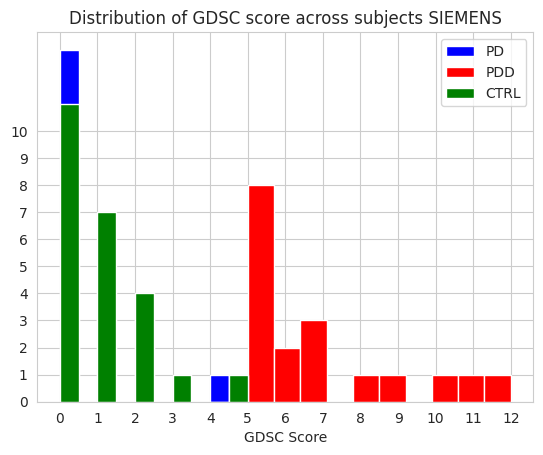

In [ ]:
plt.hist(df_siemens_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_siemens_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_siemens_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects SIEMENS")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

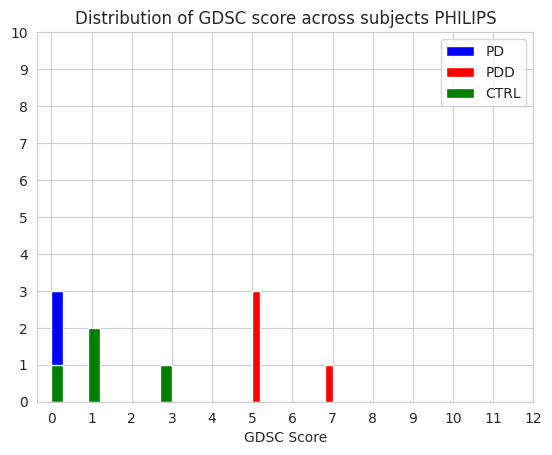

In [ ]:
plt.hist(df_philips_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_philips_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_philips_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects PHILIPS")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

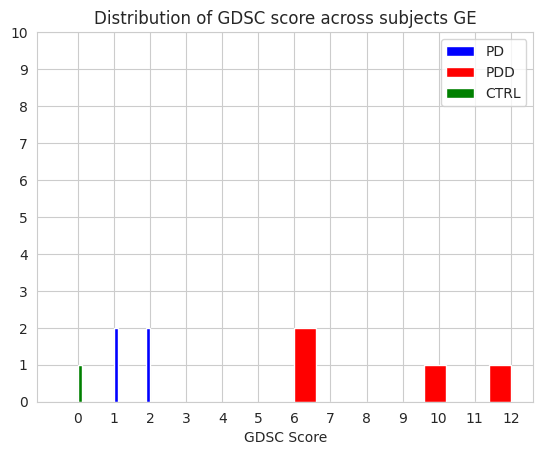

In [ ]:
plt.hist(df_ge_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_ge_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_ge_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects GE")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

In [ ]:
def get_list_paths(list_participants, root_dir):
  paths = {}
  gdsc_list= []
  for subject in list_participants:
      mat_path = (
          root_dir
          / str(subject)
          / str(subject)
          / "data"
          / "ROI_Subject001_Session001.mat"
      )
      paths[subject] = mat_path
      gdsc = all_participants[all_participants["Subject ID"]==int(subject)]["GDSCALE Total Score"].iloc[0]
      if math.isnan(gdsc):
        gdsc = 0
      gdsc_list.append(int(gdsc))
      #print(gdsc)
      #print(subject, "->", mat_path.exists())
  return paths, gdsc_list

In [ ]:
paths, gdsc_ctrl = get_list_paths(list_participants_ctrl, root_path_ctrl)
paths, gdsc_pd = get_list_paths(list_participants_pd, root_path_pd)
paths, gdsc_pdd = get_list_paths(list_participants_pdd, root_path_pd_dep)

In [ ]:
#@title EXTRACT THE REGIONS OF INTEREST
def get_individual_roi_matrix(path_name):
  path_try = loadmat(path_name)
  names = path_try["names"]
  data = path_try["data"]
  roi_names = [n[0] if isinstance(n, np.ndarray) else n for n in names[0]]
  #roi_names
  roi_idx = [
      i for i, name in enumerate(roi_names)
      if name.startswith(("networks.DefaultMode.",
                          "networks.Salience.",
                          "networks.FrontoParietal."))
  ]
  roi_interest_names = [roi_names[i] for i in roi_idx]
  roi_interest_data = [data[0, i] for i in roi_idx]
  X_interest = np.column_stack([np.asarray(arr).squeeze() for arr in roi_interest_data])
  #print("X_interest shape:", X_interest.shape)
  return X_interest, roi_interest_names

In [ ]:
def get_list_roi_matrix(status):
  X_list = []
  if status ==  "PD":
    path_names, gdsc = get_list_paths(list_participants_pd, root_path_pd)
  if status ==  "PDD":
    path_names, gdsc = get_list_paths(list_participants_pdd, root_path_pd_dep)
  if status ==  "CTRL":
    path_names, gdsc = get_list_paths(list_participants_ctrl, root_path_ctrl)

  for path in path_names.values():
    X_interest, roi_interest_names = get_individual_roi_matrix(path)
    X_list.append(X_interest)
  return X_list, roi_interest_names

#**Harmonization Technique**

In [ ]:
#@title Combat Harmonization Variables

def get_harmonization (matrix_flatten_pd, matrix_flatten_pdd, matrix_flatten_ctrl):
  X = np.vstack([matrix_flatten_pd,matrix_flatten_pdd,matrix_flatten_ctrl])
  group = ["PD"]*len(list_participants_pd) + ["PDD"]*len(list_participants_pdd) + ["CTRL"]* len(list_participants_ctrl)

  batch_pd = get_manufacturers_list(list_participants_pd)
  batch_pdd = get_manufacturers_list(list_participants_pdd)
  batch_ctrl = get_manufacturers_list(list_participants_ctrl)
  batch = np.concatenate([batch_pd, batch_pdd, batch_ctrl])

  age_pd = get_age_list(list_participants_pd)
  age_pdd = get_age_list(list_participants_pdd)
  age_ctrl = get_age_list(list_participants_ctrl)
  age = np.concatenate([age_pd, age_pdd, age_ctrl])

  sex_pd = get_sex_list(list_participants_pd)
  sex_pdd = get_sex_list(list_participants_pdd)
  sex_ctrl = get_sex_list(list_participants_ctrl)
  sex = np.concatenate([sex_pd, sex_pdd, sex_ctrl])
  sex_encoded = (np.array(sex) == "F").astype(int)

  gdsc_pd = get_gdsc_list(list_participants_pd)
  gdsc_pdd = get_gdsc_list(list_participants_pdd)
  gdsc_ctrl = get_gdsc_list(list_participants_ctrl)
  gdsc = np.concatenate([gdsc_pd, gdsc_pdd, gdsc_ctrl])


  #batch_two = np.where(batch == "Manufacturer=Philips Medical Systems;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch)
  #batch_two = np.where(batch_two == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch_two)

  print(X.shape)
  print(len(group))
  print(len(batch))

  group_dummies = pd.get_dummies(group, prefix="GROUP", drop_first=True)

  covars = pd.DataFrame({
        "SITE": batch,
        "AGE": age,
        "SEX": sex_encoded
    })

  covars = pd.concat([covars, group_dummies], axis=1)

  #print(covars.head())
  model, X_harmonized = harmonizationLearn(
      data = X,
      covars = covars
  )
  print(model.keys())
  print(X.shape, X_harmonized.shape)
  print(np.isnan(X_harmonized).sum(), np.isinf(X_harmonized).sum())
  return model, X_harmonized, group, batch, age, sex_encoded, gdsc
#model, X_harmonized = get_harmonization (matrix_flatten_pd, matrix_flatten_pdd, matrix_flatten_ctrl)

In [ ]:
def plot_combat_distributions(X_before, X_after, group, site, age=None, sex=None):

    def to_dataframe(X, label):
        data = []
        for i in range(X.shape[0]):
            for val in X[i]:
                data.append({
                    "value": val,
                    "group": group[i],
                    "site": site[i],
                    "age": age[i] if age is not None else None,
                    "sex": sex[i] if sex is not None else None,
                    "stage": label
                })
        return pd.DataFrame(data)

    df_before = to_dataframe(X_before, "Before ComBat")
    df_after  = to_dataframe(X_after, "After ComBat")
    df = pd.concat([df_before, df_after]).reset_index(drop=True)

    if age is not None:
        df["age"] = df["age"].astype(float)
        df["age_bin"] = pd.qcut(df["age"], q=3, labels=["Young", "Middle", "Old"])

    HEIGHT = 4
    ASPECT = 1.2
    TITLE_Y = 1.05

    sns.set_style("whitegrid")

    g1 = sns.FacetGrid(df, col="stage", hue="site",
                       sharex=True, sharey=True,
                       height=HEIGHT, aspect=ASPECT)

    g1.map(sns.kdeplot, "value", fill=True, alpha=0.4)
    g1.add_legend(title="Site")
    g1._legend.set_bbox_to_anchor((1.05, 0.5))

    g1.fig.suptitle("Distributions by SITE", y=TITLE_Y)
    g1.fig.tight_layout()
    plt.show()

    g2 = sns.FacetGrid(df, col="stage", hue="group",
                       sharex=True, sharey=True,
                       height=HEIGHT, aspect=ASPECT)

    g2.map(sns.kdeplot, "value", fill=True, alpha=0.4)
    g2.add_legend(title="Group")
    g2._legend.set_bbox_to_anchor((1.05, 0.5))

    g2.fig.suptitle("Distributions by GROUP", y=TITLE_Y)
    g2.fig.tight_layout()
    plt.show()

    if age is not None:
        g3 = sns.FacetGrid(df, col="stage", hue="age_bin",
                           sharex=True, sharey=True,
                           height=HEIGHT, aspect=ASPECT)

        g3.map(sns.kdeplot, "value", fill=True, alpha=0.4)
        g3.add_legend(title="Age group")
        g3._legend.set_bbox_to_anchor((1.05, 0.5))

        g3.fig.suptitle("Distributions by AGE", y=TITLE_Y)
        g3.fig.tight_layout()
        plt.show()

    if sex is not None:
        # optional: map 0/1 → labels
        df["sex_label"] = np.where(df["sex"] == 1, "F", "M")

        g4 = sns.FacetGrid(df, col="stage", hue="sex_label",
                           sharex=True, sharey=True,
                           height=HEIGHT, aspect=ASPECT)

        g4.map(sns.kdeplot, "value", fill=True, alpha=0.4)
        g4.add_legend(title="Sex")
        g4._legend.set_bbox_to_anchor((1.05, 0.5))

        g4.fig.suptitle("Distributions by SEX", y=TITLE_Y)
        g4.fig.tight_layout()
        plt.show()

#**Functional Connectivity**

In [ ]:
#@title STATIC FUNCTIONAL CONNECTIVITY
def compute_fc_matrix(status):
  fc_matrix_list = []
  X_list,roi_interest_names = get_list_roi_matrix(status)
  for x in X_list:
    fc_matrix = np.corrcoef(x.T)
    fc_matrix = np.clip(fc_matrix, -0.999999, 0.999999)
    fc_matrix = np.arctanh(fc_matrix)
    np.fill_diagonal(fc_matrix, 0)
    fc_matrix_list.append(fc_matrix)
  return np.array(fc_matrix_list)

def flatten_fc(matrix):
  return matrix[np.triu_indices_from(matrix, k = 1)]

def get_all_flatten(matrix_list):
  matrix_flatten = []
  for matrix in matrix_list:
    temp_matrix = flatten_fc(matrix)
    matrix_flatten.append(temp_matrix)
  return np.array(matrix_flatten)

In [ ]:
fc_matrix_list_pd = compute_fc_matrix(status = "PD")
matrix_flatten_pd = get_all_flatten(fc_matrix_list_pd)

print(fc_matrix_list_pd.shape)
print(matrix_flatten_pd.shape)
fc_matrix_list_pdd = compute_fc_matrix(status = "PDD")
matrix_flatten_pdd = get_all_flatten(fc_matrix_list_pdd)
print(fc_matrix_list_pdd.shape)
print(matrix_flatten_pdd.shape)
fc_matrix_list_ctrl = compute_fc_matrix(status = "CTRL")
matrix_flatten_ctrl = get_all_flatten(fc_matrix_list_ctrl)
print(fc_matrix_list_ctrl.shape)
print(matrix_flatten_ctrl.shape)

(32, 15, 15)
(32, 105)
(26, 15, 15)
(26, 105)
(32, 15, 15)
(32, 105)


(90, 105)
90
90
dict_keys(['design', 'SITE_labels', 'var_pooled', 'B_hat', 'stand_mean', 'mod_mean', 'gamma_star', 'delta_star', 'info_dict', 'gamma_hat', 'delta_hat', 'gamma_bar', 't2', 'a_prior', 'b_prior', 'smooth_model', 'eb', 'SITE_labels_train', 'Covariates', 'ref_batch'])
(90, 105) (90, 105)
0 0


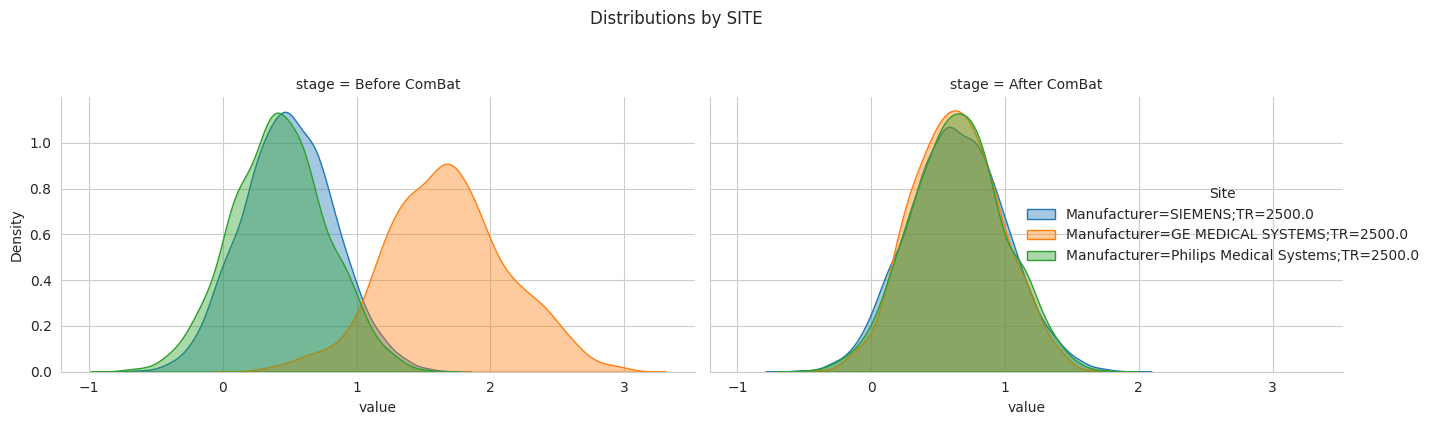

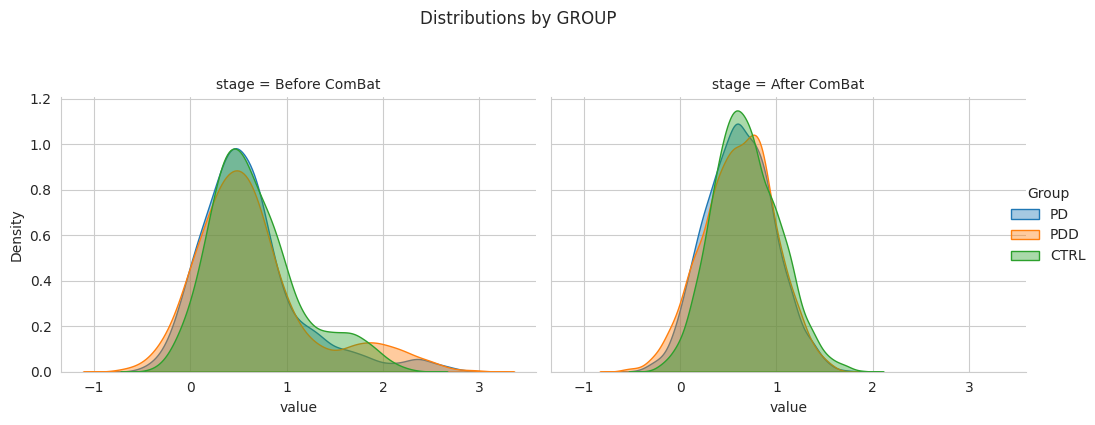

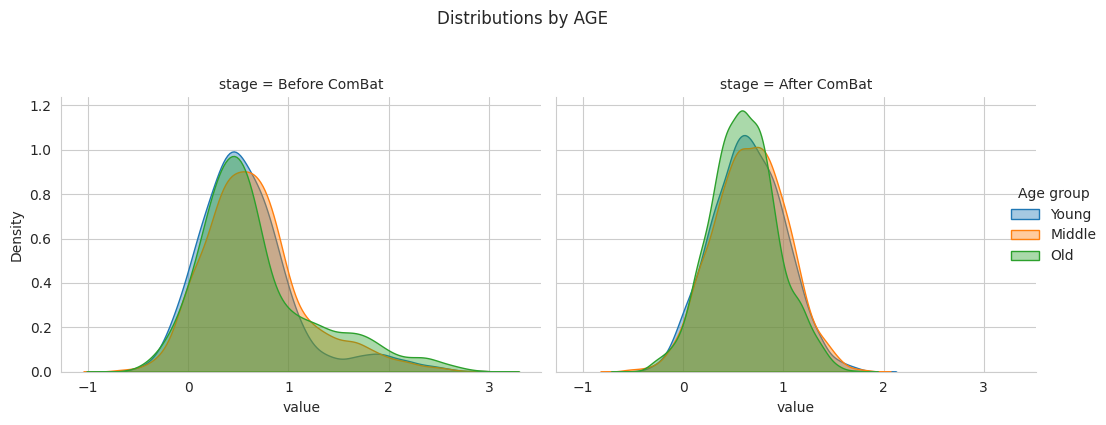

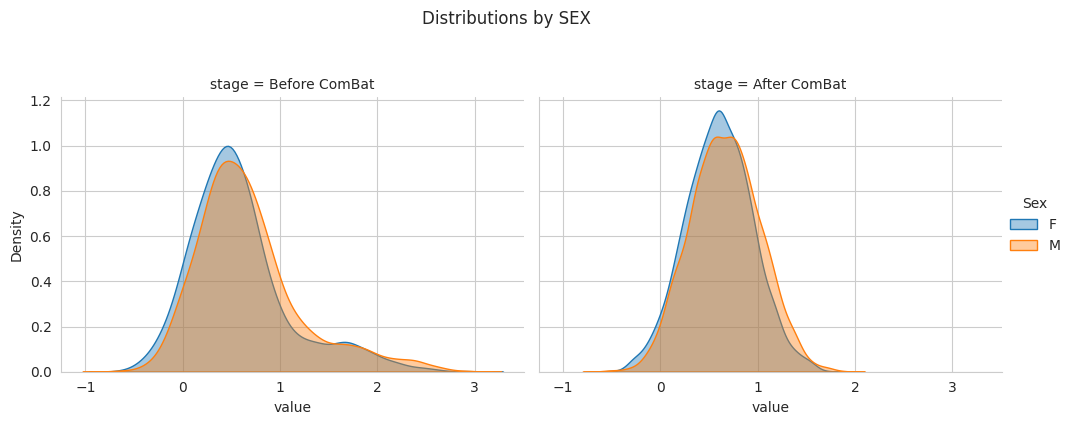

In [ ]:
#@title Harmonization
model, X_harmonized, group, batch, age, sex, gdsc = get_harmonization(
    matrix_flatten_pd,
    matrix_flatten_pdd,
    matrix_flatten_ctrl
)

plot_combat_distributions(
    X_before = np.vstack([matrix_flatten_pd, matrix_flatten_pdd, matrix_flatten_ctrl]),
    X_after  = X_harmonized,
    group    = group,
    site     = batch,
    age      = age,
    sex      = sex
)

In [ ]:
print(X_harmonized.shape)
print(len(group))
print(age.shape)
print(sex.shape)
print(batch.shape)

(90, 105)
90
(90,)
(90,)
(90,)


In [ ]:
#@title GLM MODEL
meta = pd.DataFrame({
    "Group": group,
    "Age": age,
    "Sex": sex
})

print(meta.head())

  Group   Age  Sex
0    PD  72.5    1
1    PD  55.7    1
2    PD  52.8    0
3    PD  67.2    0
4    PD  69.7    1


In [ ]:
#@title CTRL vs PD, PDD
group_dummies = pd.get_dummies(
    meta["Group"],
    drop_first=True #CTRL is my reference
)

group_dummies = group_dummies.astype(int)
print(group_dummies.head())


   PD  PDD
0   1    0
1   1    0
2   1    0
3   1    0
4   1    0


In [ ]:
X_design = pd.concat([
    group_dummies,
    meta[["Age","Sex"]]
],axis=1)

X_design = sm.add_constant(X_design)

print(X_design.head())

   const  PD  PDD   Age  Sex
0    1.0   1    0  72.5    1
1    1.0   1    0  55.7    1
2    1.0   1    0  52.8    0
3    1.0   1    0  67.2    0
4    1.0   1    0  69.7    1


In [ ]:
beta_PD = []
beta_PDD = []

p_PD = []
p_PDD = []

for edge in range(X_harmonized.shape[1]):

    y = X_harmonized[:,edge]

    fit = sm.OLS(
        y,
        X_design
    ).fit()

    beta_PD.append(
        fit.params["PD"]
    )

    beta_PDD.append(
        fit.params["PDD"]
    )

    p_PD.append(
        fit.pvalues["PD"]
    )

    p_PDD.append(
        fit.pvalues["PDD"]
    )

beta_PD = np.array(beta_PD)
beta_PDD = np.array(beta_PDD)

p_PD = np.array(p_PD)
p_PDD = np.array(p_PDD)

In [ ]:
reject_PD, p_fdr_PD = fdrcorrection(
    p_PD,
    alpha=0.05
)

reject_PDD, p_fdr_PDD = fdrcorrection(
    p_PDD,
    alpha=0.05
)

In [ ]:
results = pd.DataFrame({
    "edge": np.arange(105),

    "beta_PD": beta_PD,
    "p_PD": p_PD,
    "p_fdr_PD": p_fdr_PD,

    "beta_PDD": beta_PDD,
    "p_PDD": p_PDD,
    "p_fdr_PDD": p_fdr_PDD
})

results.sort_values(
    "p_PDD"
).head(20)

,edge,beta_PD,p_PD,p_fdr_PD,beta_PDD,p_PDD,p_fdr_PDD
37,37,-0.105295,0.107577,0.470648,-0.220528,0.001924,0.202018
32,32,-0.100125,0.164633,0.500822,-0.208590,0.007388,0.292863
33,33,-0.180980,0.012213,0.463469,-0.200021,0.009339,0.292863
31,31,-0.164598,0.028759,0.463469,-0.189069,0.018498,0.292863
22,22,-0.066377,0.417749,0.674826,-0.200684,0.023084,0.292863
28,28,-0.153852,0.073077,0.463469,-0.204727,0.025751,0.292863
17,17,-0.106497,0.125215,0.489472,-0.163905,0.027702,0.292863
50,50,-0.141656,0.074663,0.463469,-0.186779,0.027935,0.292863
43,43,-0.134067,0.051159,0.463469,-0.159648,0.029512,0.292863
8,8,-0.146827,0.077344,0.463469,-0.192685,0.030128,0.292863


In [ ]:
mask = meta["Group"].isin([
    "PD",
    "PDD"
])

X_sub = X_harmonized[mask]

meta_sub = meta[
    mask
].copy()

In [ ]:
meta_sub["PDD"] = (
    meta_sub["Group"]=="PDD"
).astype(int)

print(
    meta_sub[
        ["Group","PDD"]
    ].head()
)

  Group  PDD
0    PD    0
1    PD    0
2    PD    0
3    PD    0
4    PD    0


In [ ]:
X_design_sub = meta_sub[
    [
        "PDD",
        "Age",
        "Sex"
    ]
]

X_design_sub = sm.add_constant(
    X_design_sub
)

print(
    X_design_sub.head()
)

   const  PDD   Age  Sex
0    1.0    0  72.5    1
1    1.0    0  55.7    1
2    1.0    0  52.8    0
3    1.0    0  67.2    0
4    1.0    0  69.7    1


In [ ]:
beta = []
pvals = []

for edge in range(
    X_sub.shape[1]
):

    y = X_sub[:,edge]

    fit = sm.OLS(
        y,
        X_design_sub
    ).fit()

    beta.append(
        fit.params["PDD"]
    )

    pvals.append(
        fit.pvalues["PDD"]
    )

beta = np.array(beta)
pvals = np.array(pvals)

In [ ]:
reject,p_fdr = fdrcorrection(
    pvals,
    alpha=0.05
)

In [ ]:
results_pd_pdd = pd.DataFrame({
    "edge":np.arange(105),
    "beta":beta,
    "p":pvals,
    "p_fdr":p_fdr,
    "sig":reject
})

results_pd_pdd.sort_values(
    "p"
).head(20)

,edge,beta,p,p_fdr,sig
80,80,0.141877,0.055489,0.96217,False
81,81,0.120352,0.071056,0.96217,False
78,78,0.112512,0.086622,0.96217,False
37,37,-0.108544,0.089723,0.96217,False
92,92,0.113387,0.111781,0.96217,False
0,0,-0.112877,0.130534,0.96217,False
91,91,0.120719,0.133843,0.96217,False
22,22,-0.126236,0.139179,0.96217,False
62,62,-0.093460,0.149641,0.96217,False
32,32,-0.104500,0.154792,0.96217,False


In [ ]:
def run_glm_fc(
    X_fc,
    meta,
    predictors,
    target="PDD",
    fdr=True
):

    X_design = meta[predictors].copy()

    X_design = sm.add_constant(
        X_design
    )

    betas = []
    pvals = []

    for edge in range(
        X_fc.shape[1]
    ):

        y = X_fc[:,edge]

        fit = sm.OLS(
            y,
            X_design
        ).fit()

        betas.append(
            fit.params[target]
        )

        pvals.append(
            fit.pvalues[target]
        )

    betas = np.array(betas)
    pvals = np.array(pvals)

    if fdr:

        reject,p_fdr = fdrcorrection(
            pvals,
            alpha=0.05
        )

    else:

        reject = np.zeros(
            len(pvals)
        )

        p_fdr = pvals

    results = pd.DataFrame({

        "edge":
        np.arange(
            len(betas)
        ),

        "beta":
        betas,

        "p":
        pvals,

        "p_fdr":
        p_fdr,

        "sig":
        reject
    })

    return results.sort_values(
        "p"
    )

In [ ]:
meta.groupby(
    "Group"
)["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
CTRL,32.0,65.668750,12.572254,32.2,58.600,67.30,76.075,85.3
PD,32.0,64.056250,10.685563,39.4,58.475,65.55,71.450,82.4
PDD,26.0,62.907692,9.925036,41.9,55.925,63.70,69.075,80.5


In [ ]:
pd.crosstab(
    meta["Group"],
    meta["Sex"]
)

Sex,0,1
Group,,
CTRL,18,14
PD,19,13
PDD,18,8


In [ ]:
#@title WHICH ONE KILLS THE SIGNIFICANCE?
from IPython.display import display
results_pd_pdd = run_glm_fc(

    X_fc = X_sub,

    meta = meta_sub,

    predictors = [
        "PDD"
    ],

    target = "PDD"
)

display(
    results_pd_pdd[results_pd_pdd["sig"] == "True"]
)

,edge,beta,p,p_fdr,sig


In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection

pvals = []
effect = []

for edge in range(X_sub.shape[1]):

    pd_values = X_sub[
        meta_sub["PDD"]==0,
        edge
    ]

    pdd_values = X_sub[
        meta_sub["PDD"]==1,
        edge
    ]

    stat,p = mannwhitneyu(
        pd_values,
        pdd_values,
        alternative="two-sided"
    )

    pvals.append(p)

    effect.append(
        np.mean(pdd_values)
        -
        np.mean(pd_values)
    )

pvals = np.array(pvals)

reject,p_fdr = fdrcorrection(
    pvals
)

results_mw = pd.DataFrame({
    "edge":np.arange(105),
    "effect":effect,
    "p":pvals,
    "p_fdr":p_fdr,
    "sig":reject
})

results_mw.sort_values(
    "p"
).head(20)

,edge,effect,p,p_fdr,sig
78,78,0.113215,0.031568,0.990725,False
0,0,-0.125905,0.032826,0.990725,False
81,81,0.117893,0.055453,0.990725,False
80,80,0.141630,0.061706,0.990725,False
15,15,-0.097061,0.092805,0.990725,False
37,37,-0.117402,0.123544,0.990725,False
36,36,-0.066543,0.131351,0.990725,False
1,1,-0.123440,0.131351,0.990725,False
92,92,0.113014,0.157073,0.990725,False
22,22,-0.124174,0.157073,0.990725,False


In [ ]:
from scipy.stats import shapiro

normal_edges = []
non_normal_edges = []

for edge in range(X_sub.shape[1]):

    stat,p = shapiro(
        X_sub[:,edge]
    )

    if p > 0.05:
        normal_edges.append(edge)

    else:
        non_normal_edges.append(edge)

print(
    "Normal:",
    len(normal_edges)
)

print(
    "Non normal:",
    len(non_normal_edges)
)

Normal: 94
Non normal: 11


In [ ]:
fit = sm.OLS(
    X_sub[:,0],
    X_design_sub
).fit()

shapiro(
    fit.resid
)

ShapiroResult(statistic=np.float64(0.9776963020015758), pvalue=np.float64(0.360937001739125))

In [ ]:
normal_resid = []
non_normal_resid = []

for edge in range(X_sub.shape[1]):

    y = X_sub[:,edge]

    fit = sm.OLS(
        y,
        X_design_sub
    ).fit()

    stat,p = shapiro(
        fit.resid
    )

    if p > 0.05:
        normal_resid.append(edge)

    else:
        non_normal_resid.append(edge)

print(
    "Normal residuals:",
    len(normal_resid)
)

print(
    "Non normal residuals:",
    len(non_normal_resid)
)

Normal residuals: 95
Non normal residuals: 10


In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

homogeneous = []
heterogeneous = []

for edge in range(X_sub.shape[1]):

    y = X_sub[:,edge]

    fit = sm.OLS(
        y,
        X_design_sub
    ).fit()

    bp = het_breuschpagan(
        fit.resid,
        fit.model.exog
    )

    p = bp[1]

    if p > 0.05:

        homogeneous.append(edge)

    else:

        heterogeneous.append(edge)

print(
    "Homogeneous:",
    len(homogeneous)
)

print(
    "Heterogeneous:",
    len(heterogeneous)
)

Homogeneous: 98
Heterogeneous: 7


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = X_design_sub.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_design_sub.values,
        i
    )

    for i in range(
        X_design_sub.shape[1]
    )
]

print(vif)

  Variable        VIF
0    const  41.484972
1      PDD   1.012141
2      Age   1.029118
3      Sex   1.036666


In [ ]:
results_pd_pdd_age = run_glm_fc(

    X_fc = X_sub,

    meta = meta_sub,

    predictors = [
        "PDD",
        "Age"
    ],

    target = "PDD"
)

display(
    results_pd_pdd_age[results_pd_pdd_age["sig"] == "True"]
)

,edge,beta,p,p_fdr,sig


In [ ]:
mask_valid = ~np.isnan(gdsc)

meta_gds = meta[
    mask_valid
].copy()

X_gds = X_harmonized[
    mask_valid
]

print(X_gds.shape)
print(meta_gds.shape)

(87, 105)
(87, 3)


In [ ]:
print(np.isnan(gdsc).sum())
print(np.isinf(gdsc).sum())

print(meta["GDS"].isna().sum())

3
0
3


In [ ]:
meta_gds["GDS"] = gdsc[mask_valid]
results_gds = run_glm_fc(
    X_fc = X_gds,

    meta = meta_gds,

    predictors = [
        "GDS",
        "Age",
        "Sex"
    ],

    target = "GDS"
)

display(
    results_gds.head(20)
)

,edge,beta,p,p_fdr,sig
37,37,-0.023332,0.011707,0.892914,False
32,32,-0.021428,0.033765,0.892914,False
22,22,-0.023941,0.036295,0.892914,False
8,8,-0.021936,0.056253,0.892914,False
16,16,-0.017981,0.078201,0.892914,False
0,0,-0.015307,0.105528,0.892914,False
43,43,-0.015201,0.112752,0.892914,False
81,81,0.013864,0.117700,0.892914,False
53,53,-0.017451,0.124013,0.892914,False
45,45,-0.015665,0.129998,0.892914,False


In [ ]:
roi_interest_names = get_roi_names()

print(len(roi_interest_names))
print(roi_interest_names)

n_roi = len(roi_interest_names)

iu = np.triu_indices(
    n_roi,
    k=1
)

edge_names = []

for i,j in zip(
    iu[0],
    iu[1]
):

    edge_names.append(
        f"{roi_interest_names[i]} -> {roi_interest_names[j]}"
    )

print(len(edge_names))

15
[np.str_('networks.DefaultMode.MPFC (1,55,-3)'), np.str_('networks.DefaultMode.LP (L) (-39,-77,33)'), np.str_('networks.DefaultMode.LP (R) (47,-67,29)'), np.str_('networks.DefaultMode.PCC (1,-61,38)'), np.str_('networks.Salience.ACC (0,22,35)'), np.str_('networks.Salience.AInsula (L) (-44,13,1)'), np.str_('networks.Salience.AInsula (R) (47,14,0)'), np.str_('networks.Salience.RPFC (L) (-32,45,27)'), np.str_('networks.Salience.RPFC (R) (32,46,27)'), np.str_('networks.Salience.SMG (L) (-60,-39,31)'), np.str_('networks.Salience.SMG (R) (62,-35,32)'), np.str_('networks.FrontoParietal.LPFC (L)  (-43,33,28)'), np.str_('networks.FrontoParietal.PPC (L)  (-46,-58,49)'), np.str_('networks.FrontoParietal.LPFC (R)  (41,38,30)'), np.str_('networks.FrontoParietal.PPC (R)  (52,-52,45)')]
105


In [ ]:
pd.set_option(
    "display.max_colwidth",
    None
)

results_gds["edge_name"] = edge_names

display(
    results_gds[
        results_gds["p"] < 0.05
    ][[
        "edge_name",
        "beta",
        "p",
        "p_fdr"
    ]]
)

,edge_name,beta,p,p_fdr
37,"networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.LP (L) (-39,-77,33)",-0.023332,0.011707,0.892914
32,"networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.LP (R) (47,-67,29)",-0.021428,0.033765,0.892914
22,"networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.PCC (1,-61,38)",-0.023941,0.036295,0.892914


In [ ]:
import re

adj_significant = np.zeros(
    (len(coords),len(coords))
)

for _,row in significant_results.iterrows():

    edge = row["edge_name"]

    src = edge.split("->")[0]
    tgt = edge.split("->")[1]

    src_idx = next(
        i for i,r in enumerate(
            roi_interest_names
        )
        if src.strip() == r.strip()
    )

    tgt_idx = next(
        i for i,r in enumerate(
            roi_interest_names
        )
        if tgt.strip() == r.strip()
    )

    adj_significant[
        src_idx,
        tgt_idx
    ] = row["beta"]

    adj_significant[
        tgt_idx,
        src_idx
    ] = row["beta"]

In [ ]:
for i,j in zip(
    *np.where(adj_significant != 0)
):

    if i < j:

        print(
            roi_interest_names[i],
            "->",
            roi_interest_names[j]
        )

networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.LP (L) (-39,-77,33)
networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.LP (R) (47,-67,29)
networks.DefaultMode.MPFC (1,55,-3) -> networks.DefaultMode.PCC (1,-61,38)


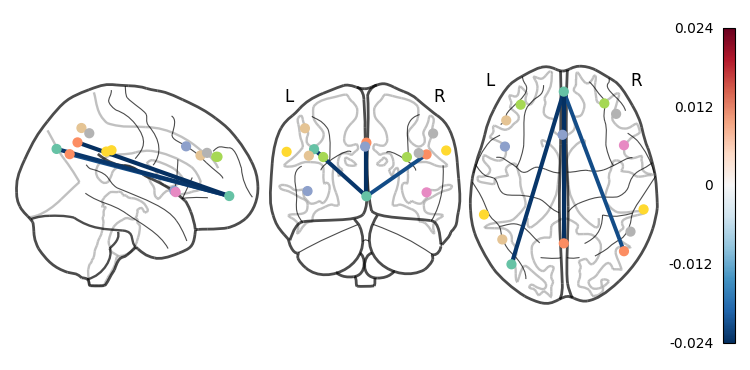

In [ ]:
plotting.plot_connectome(
    adj_significant,
    coords,

    edge_threshold=0,

    #title= "Exploratory GDS-related DMN alterations\n(p < 0.05 uncorrected)",

    display_mode="ortho",

    node_size=40
)

plt.show()

In [ ]:
save_to_plot(
    adj_significant,
    coords,
    get_list_names(),
    name="GDS_DMN"
)

In [ ]:
edge_mpfc_lpl = 37
edge_mpfc_lpr = 32
edge_mpfc_pcc = 22

In [ ]:
dmn_score = (
    X_gds[:, edge_mpfc_lpl] +
    X_gds[:, edge_mpfc_lpr] +
    X_gds[:, edge_mpfc_pcc]
) / 3

In [ ]:
meta_gds["DMN_score"] = dmn_score

In [ ]:
display(
    meta_gds[X
        [
            "Group",
            "GDS",
            "DMN_score"
        ]
    ].head()
)

,Group,GDS,DMN_score
0,PD,0.0,0.463047
1,PD,2.0,0.629909
2,PD,0.0,0.546407
3,PD,0.0,0.927836
4,PD,5.0,0.596370


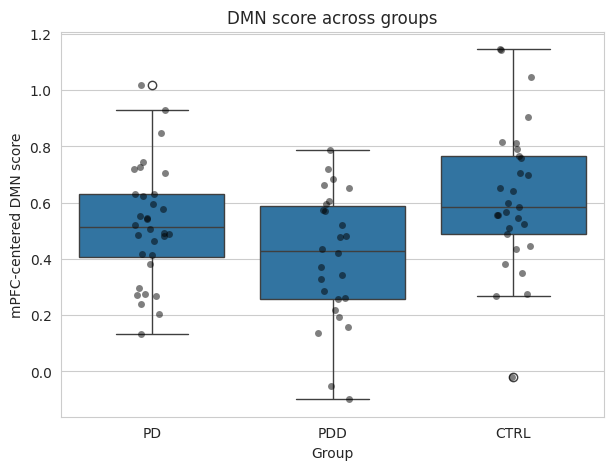

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=meta_gds,
    x="Group",
    y="DMN_score"
)

sns.stripplot(
    data=meta_gds,
    x="Group",
    y="DMN_score",

    color="black",
    alpha=0.5
)

plt.ylabel(
    "mPFC-centered DMN score"
)

plt.title(
    "DMN score across groups"
)

plt.show()

In [ ]:
from scipy.stats import kruskal

ctrl = meta_gds.loc[
    meta_gds["Group"]=="CTRL",
    "DMN_score"
]

pd_ = meta_gds.loc[
    meta_gds["Group"]=="PD",
    "DMN_score"
]

pdd = meta_gds.loc[
    meta_gds["Group"]=="PDD",
    "DMN_score"
]

print(
    kruskal(
        ctrl,
        pd_,
        pdd
    )
)

KruskalResult(statistic=np.float64(9.050271202489569), pvalue=np.float64(0.010833245335279918))


In [ ]:
from scipy.stats import mannwhitneyu

pairs = [
    ("CTRL","PD"),
    ("CTRL","PDD"),
    ("PD","PDD")
]

for g1,g2 in pairs:

    x = meta_gds.loc[
        meta_gds["Group"]==g1,
        "DMN_score"
    ]

    y = meta_gds.loc[
        meta_gds["Group"]==g2,
        "DMN_score"
    ]

    stat,p = mannwhitneyu(
        x,y,
        alternative="two-sided"
    )

    print(
        g1,
        g2,
        p
    )

CTRL PD 0.08971378961463826
CTRL PDD 0.004270422102966041
PD PDD 0.10228477073348033


In [ ]:
meta_gds.groupby(
    "Group"
)["DMN_score"].agg(
    ["mean","std"]
)

,mean,std
Group,,
CTRL,0.618964,0.258711
PD,0.523090,0.208407
PDD,0.407198,0.232814


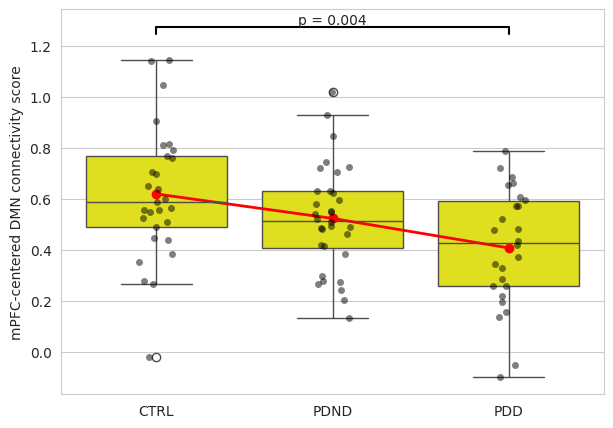

In [ ]:
plt.figure(
    figsize=(7,5)
)

sns.boxplot(
    data=meta_gds,

    x="Group",

    y="DMN_score",

    order=[
        "CTRL",
        "PD",
        "PDD"
    ],
    color="yellow"
)

sns.stripplot(
    data=meta_gds,

    x="Group",

    y="DMN_score",

    order=[
        "CTRL",
        "PD",
        "PDD"
    ],

    color="black",

    alpha=0.5
)

means = (
    meta_gds
    .groupby(
        "Group"
    )["DMN_score"]
    .mean()
)

means = means.loc[
    [
        "CTRL",
        "PD",
        "PDD"
    ]
]

plt.plot(
    range(3),

    means,

    marker="o",

    linewidth=2,
    color = "red"
)

plt.ylabel(
    "mPFC-centered DMN connectivity score"
)

plt.xlabel("")


#plt.title("DMN connectivity score across groups")
plt.xticks(
    ticks=range(3),

    labels=[
        "CTRL",
        "PDND",
        "PDD"
    ]
)

y = meta_gds["DMN_score"].max() + 0.1

plt.plot(
    [0,0,2,2],

    [y,y+0.03,y+0.03,y],

    lw=1.5,

    color="black"
)

plt.text(
    1,

    y+0.04,

    "p = 0.004",

    ha="center"
)

plt.show()

In [ ]:
meta[
    np.isnan(gdsc)
][[
    "Group",
    "Age",
    "Sex",
    "GDS"
]]

In [ ]:
mask = meta_gds["Group"].isin(
    ["PD","PDD"]
)

meta_gds_sub = meta_gds[
    mask
].copy()

X_gds_sub = X_gds[
    mask
]

print(X_gds_sub.shape)

In [ ]:
results_gds_pd = run_glm_fc(
    X_fc = X_gds_sub,

    meta = meta_gds_sub,

    predictors = [
        "GDS",
        "Age",
        "Sex"
    ],

    target = "GDS"
)

display(
    results_gds_pd.head(20)
)

In [ ]:
results_gds_pd["edge_name"] = edge_names

display(
    results_gds_pd[
        results_gds_pd["p"] < 0.05
    ][[
        "edge_name",
        "beta",
        "p"
    ]]
)

In [ ]:
import matplotlib.pyplot as plt

edge = 81

plt.figure(figsize=(6,5))

plt.scatter(
    meta_gds_sub["GDS"],
    X_gds_sub[:,edge]
)

plt.xlabel("GDS")
plt.ylabel("mPFC-LP(L) FC")

plt.title(
    "mPFC-LP(L) vs GDS"
)

plt.show()

In [ ]:
from scipy.stats import pearsonr

r,p = pearsonr(
    meta_gds_sub["GDS"],
    X_gds_sub[:,81]
)

print(r,p)

In [ ]:
import matplotlib.pyplot as plt

colors = meta_gds_sub["Group"].map({
    "PD":"blue",
    "PDD":"red"
})

plt.figure(figsize=(6,5))

plt.scatter(
    meta_gds_sub["GDS"],
    X_gds_sub[:,81],
    c = colors
)

plt.xlabel("GDS")
plt.ylabel("mPFC-LP(L) FC")

plt.title(
    f"r={r:.2f}, p={p:.3f}"
)

plt.show()

In [ ]:
from scipy.stats import pearsonr

pd_mask = meta_gds_sub["Group"]=="PD"
pdd_mask = meta_gds_sub["Group"]=="PDD"

r_pd,p_pd = pearsonr(
    meta_gds_sub.loc[pd_mask,"GDS"],
    X_gds_sub[pd_mask,81]
)

r_pdd,p_pdd = pearsonr(
    meta_gds_sub.loc[pdd_mask,"GDS"],
    X_gds_sub[pdd_mask,81]
)

print(
    "PD:",
    r_pd,p_pd
)

print(
    "PDD:",
    r_pdd,p_pdd
)

In [ ]:
import seaborn as sns

plot_df = pd.DataFrame({
    "GDS":meta_gds_sub["GDS"],
    "FC":X_gds_sub[:,81],
    "Group":meta_gds_sub["Group"]
})

sns.lmplot(
    data=plot_df,
    x="GDS",
    y="FC",
    hue="Group",
    ci=None
)

In [ ]:
n_pd = matrix_flatten_pd.shape[0]
n_pdd = matrix_flatten_pdd.shape[0]
n_ctrl = matrix_flatten_ctrl.shape[0]

X_pd_h = X_harmonized[:n_pd]
X_pdd_h = X_harmonized[n_pd:n_pd+n_pdd]
X_ctrl_h = X_harmonized[n_pd+n_pdd:]

In [ ]:
def unflatten_fc(X, n_roi=15):
    mats = np.zeros((X.shape[0], n_roi, n_roi))
    rows, cols = np.triu_indices(n_roi, k=1)

    for s in range(X.shape[0]):
        mats[s, rows, cols] = X[s]
        mats[s, cols, rows] = X[s]

    return mats

FC_pd_h = unflatten_fc(X_pd_h)
FC_pdd_h = unflatten_fc(X_pdd_h)
FC_ctrl_h = unflatten_fc(X_ctrl_h)

In [ ]:
FC_pd_pdd = np.vstack([FC_pd_h, FC_pdd_h])
gdsc_pd_pdd = np.concatenate([gdsc_pd, gdsc_pdd])

group_pd_pdd = np.array(["PD"] * len(FC_pd_h) + ["PDD"] * len(FC_pdd_h))
mask_pdd = group_pd_pdd == "PDD"

In [ ]:
def compute_network_fc(FC, idx_a, idx_b):
    values = []

    for s in range(FC.shape[0]):
        mat = FC[s]
        block = mat[np.ix_(idx_a, idx_b)]
        values.append(np.mean(block))

    return np.array(values)

In [ ]:
dmn_fpn = compute_network_fc(FC_pd_pdd, DMN, FPN)
sal_fpn = compute_network_fc(FC_pd_pdd, SAL, FPN)
sal_dmn = compute_network_fc(FC_pd_pdd, SAL, DMN)

In [ ]:
from scipy.stats import spearmanr

print("DMN-FPN:", spearmanr(dmn_fpn, gdsc_pd_pdd))
print("SAL-FPN:", spearmanr(sal_fpn, gdsc_pd_pdd))
print("SAL-DMN:", spearmanr(sal_dmn, gdsc_pd_pdd))

In [ ]:
print("PDD only DMN-FPN:", spearmanr(dmn_fpn[mask_pdd], gdsc_pd_pdd[mask_pdd]))
print("PDD only SAL-FPN:", spearmanr(sal_fpn[mask_pdd], gdsc_pd_pdd[mask_pdd]))
print("PDD only SAL-DMN:", spearmanr(sal_dmn[mask_pdd], gdsc_pd_pdd[mask_pdd]))

In [ ]:
def compute_within_fc(FC, idx):
    values = []
    for s in range(FC.shape[0]):
        mat = FC[s]
        block = mat[np.ix_(idx, idx)]
        values.append(np.mean(block))
    return np.array(values)

In [ ]:
dmn_internal = compute_within_fc(FC_pd_pdd, DMN)
spearmanr(dmn_internal[mask_pdd], gdsc_pd_pdd[mask_pdd])

In [ ]:
def node_strength(FC):
    return np.mean(FC, axis=2)  # mean connectivity per node

strength = node_strength(FC_pd_pdd)

# example: mPFC
mpfc_strength = strength[:, mpfc_idx]
spearmanr(mpfc_strength[mask_pdd], gdsc_pd_pdd[mask_pdd])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Extract PDD only ----
x = mpfc_strength[mask_pdd]
y = gdsc_pd_pdd[mask_pdd]

# ---- Fit line (for visualization) ----
coef = np.polyfit(x, y, 1)
line = np.poly1d(coef)

# sort for clean line
idx = np.argsort(x)

# ---- Plot ----
plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.7)
plt.plot(x[idx], line(x[idx]))

plt.xlabel("mPFC connectivity strength")
plt.ylabel("GDS score (depression severity)")
plt.title("mPFC connectivity vs depression severity\nr = -0.49, p = 0.011")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# =========================
# 1. Compute node strength
# =========================
def node_strength(FC):
    return np.mean(FC, axis=2)  # mean connectivity per node

strength = node_strength(FC_pd_pdd)

# =========================
# 2. Extract mPFC strength
# =========================
mpfc_idx = candidate_nodes["mPFC"]
mpfc_strength = strength[:, mpfc_idx]

# =========================
# 3. Select PDD subjects
# =========================
x = mpfc_strength[mask_pdd]
y = gdsc_pd_pdd[mask_pdd]

# =========================
# 4. Correlation
# =========================
r, p = spearmanr(x, y)

# (optional: your computed FDR value)
p_fdr = 0.0569  # replace if recomputed

# =========================
# 5. Plot style
# =========================
sns.set(style="whitegrid", context="talk")

# =========================
# 6. Plot
# =========================
plt.figure(figsize=(7,6))

sns.regplot(
    x=x,
    y=y,
    ci=95,  # confidence band
    scatter_kws={
        "s": 80,        # point size
        "alpha": 0.8    # transparency
    },
    line_kws={
        "linewidth": 2.5,
        "color": "black"
    },
    color="#4C72B0"     # main color
)

# =========================
# 7. Labels
# =========================
plt.xlabel("mPFC connectivity strength")
plt.ylabel("GDS score (depression severity)")

# =========================
# 8. Title
# =========================
plt.title(
    f"mPFC connectivity vs depression severity\n"
    f"r = {r:.2f}, p = {p:.3f} (pFDR ≈ {p_fdr:.3f})"
)

# =========================
# 9. Clean look
# =========================
sns.despine()
plt.tight_layout()

# =========================
# 10. Save (optional)
# =========================
# plt.savefig("mpfc_vs_gds.png", dpi=300)

plt.show()

In [ ]:
# PCC (DMN core)
pcc_idx = [i for i, r in enumerate(roi_names_clean) if "PCC" in r][0]

pcc_strength = strength[:, pcc_idx]
spearmanr(pcc_strength[mask_pdd], gdsc_pd_pdd[mask_pdd])

In [ ]:
insula_idx = [i for i, r in enumerate(roi_names_clean) if "AInsula (R)" in r][0]

insula_strength = strength[:, insula_idx]
spearmanr(insula_strength[mask_pdd], gdsc_pd_pdd[mask_pdd])

In [ ]:
#“I am testing a SMALL set of theoretically relevant regions”
from statsmodels.stats.multitest import multipletests
p_values = [
    0.01137097100074054,   # mPFC
    0.34727750103376753,   # PCC
    0.8057509531892366     # Insula
]



rej, p_fdr, _, _ = multipletests(p_values, method='fdr_bh')
# → mPFC is a severity-sensitive hub in PD depression
print(p_fdr)

In [ ]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import numpy as np

# define nodes automatically
candidate_nodes = {}

for i, r in enumerate(roi_names_clean):
    if "MPFC" in r:
        candidate_nodes["mPFC"] = i
    elif "PCC" in r:
        candidate_nodes["PCC"] = i
    elif "AInsula (R)" in r:
        candidate_nodes["Insula_R"] = i
    elif "AInsula (L)" in r:
        candidate_nodes["Insula_L"] = i
    elif "SMG (L)" in r:
        candidate_nodes["SMG_L"] = i
    elif "SMG (R)" in r:
        candidate_nodes["SMG_R"] = i
    elif "PPC (L)" in r:
        candidate_nodes["PPC_L"] = i
    elif "PPC (R)" in r:
        candidate_nodes["PPC_R"] = i

In [ ]:
strength = np.mean(FC_pd_pdd, axis=2)

In [ ]:
results = []
p_values = []

for name, idx in candidate_nodes.items():
    x = strength[:, idx]
    r, p = spearmanr(x[mask_pdd], gdsc_pd_pdd[mask_pdd])

    results.append((name, r, p))
    p_values.append(p)

In [ ]:
reject, p_fdr, _, _ = multipletests(p_values, method='fdr_bh')

In [ ]:
for (name, r, p), pfdr, sig in zip(results, p_fdr, reject):
    print(f"{name}: r={r:.3f}, p={p:.4f}, pFDR={pfdr:.4f}, significant={sig}")

In [ ]:
candidate_edges = {
    "mPFC-SMG_L": (mpfc_idx, candidate_nodes["SMG_L"]),
    "mPFC-SMG_R": (mpfc_idx, candidate_nodes["SMG_R"]),
    "mPFC-PPC_L": (mpfc_idx, candidate_nodes["PPC_L"]),
    "mPFC-PPC_R": (mpfc_idx, candidate_nodes["PPC_R"]),
    "SMG_L-PPC_L": (candidate_nodes["SMG_L"], candidate_nodes["PPC_L"]),
    "SMG_R-PPC_R": (candidate_nodes["SMG_R"], candidate_nodes["PPC_R"]),
}

results = []
pvals = []

for name, (i, j) in candidate_edges.items():
    x = FC_pd_pdd[:, i, j]
    r, p = spearmanr(x[mask_pdd], gdsc_pd_pdd[mask_pdd])
    results.append((name, r, p))
    pvals.append(p)

reject, p_fdr, _, _ = multipletests(pvals, method="fdr_bh")

for (name, r, p), pfdr, sig in zip(results, p_fdr, reject):
    print(f"{name}: r={r:.3f}, p={p:.4f}, pFDR={pfdr:.4f}, significant={sig}")

In [ ]:
mpfc_strength = strength[:, mpfc_idx]

In [ ]:
x = mpfc_strength[mask_pdd]
y = gdsc_pd_pdd[mask_pdd]

In [ ]:
from scipy.stats import spearmanr

r, p = spearmanr(x, y)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,5))

# scatter
plt.scatter(x, y, s=60)

# regression line (simple linear fit just for visualization)
coef = np.polyfit(x, y, 1)
line = np.poly1d(coef)
x_sorted = np.sort(x)
plt.plot(x_sorted, line(x_sorted))

# labels
plt.xlabel("mPFC connectivity strength")
plt.ylabel("GDSC score")

# title with stats
plt.title(f"mPFC connectivity vs depression severity\nr = {r:.2f}, p = {p:.3f}")

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
y_jitter = y + np.random.normal(0, 0.1, size=len(y))
plt.scatter(x, y_jitter)

In [ ]:
import seaborn as sns

sns.regplot(x=x, y=y, scatter_kws={"s":60})

In [ ]:
bilateral_nodes = {
    "mPFC": [candidate_nodes["mPFC"]],
    "PCC": [candidate_nodes["PCC"]],
    "AInsula": [candidate_nodes["Insula_L"], candidate_nodes["Insula_R"]],
    "SMG": [candidate_nodes["SMG_L"], candidate_nodes["SMG_R"]],
    "PPC": [candidate_nodes["PPC_L"], candidate_nodes["PPC_R"]],
}

results = []
pvals = []

for name, idx_list in bilateral_nodes.items():
    x = np.mean(strength[:, idx_list], axis=1)
    r, p = spearmanr(x[mask_pdd], gdsc_pd_pdd[mask_pdd])
    results.append((name, r, p))
    pvals.append(p)

reject, p_fdr, _, _ = multipletests(pvals, method="fdr_bh")

for (name, r, p), pfdr, sig in zip(results, p_fdr, reject):
    print(f"{name}: r={r:.3f}, p={p:.4f}, pFDR={pfdr:.4f}, significant={sig}")

    # a trend-level or borderline effect
    #AInsula → biologically meaningful region

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

# ---- mPFC index ----
mpfc_idx = candidate_nodes["mPFC"]

# ---- Node strength (already computed) ----
x = strength[:, mpfc_idx]

# ---- Select PDD subjects ----
x_pdd = x[mask_pdd]
y_pdd = gdsc_pd_pdd[mask_pdd]

# ---- Correlation ----
r, p = spearmanr(x_pdd, y_pdd)

# ---- Fit line (for visualization only) ----
coef = np.polyfit(x_pdd, y_pdd, 1)
line = np.poly1d(coef)

# ---- Sort for clean line ----
idx = np.argsort(x_pdd)

# ---- Plot ----
plt.figure(figsize=(6,5))

plt.scatter(x_pdd, y_pdd, alpha=0.7)

plt.plot(x_pdd[idx], line(x_pdd[idx]))

plt.xlabel("mPFC connectivity strength")
plt.ylabel("GDS score (depression severity)")
plt.title(f"mPFC vs GDS\nr = {r:.2f}, p = {p:.3f}")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def statistical_test(X, index_1, index_2):
    p_values = []
    directions = []

    for i in range(X.shape[1]):
        x1 = X[index_1, i]
        x2 = X[index_2, i]

        _, p = mannwhitneyu(x1, x2, alternative="two-sided")
        p_values.append(p)

        # store direction
        if np.median(x2) > np.median(x1):
            directions.append("increase (group2 > group1)")
        elif np.median(x2) < np.median(x1):
            directions.append("decrease (group2 < group1)")
        else:
            directions.append("no change")

    p_values = np.array(p_values)
    sig_idx = np.where(p_values < 0.05)[0]

    print(f"Significant (uncorrected): {len(sig_idx)}")
    for idx in sig_idx:
        print(f"Feature {idx}: {directions[idx]}")

    return p_values, sig_idx

def statistical_correction(p_values):
  multipletests(p_values, method="fdr_bh")
  reject, p_fdr, _, _ = multipletests(p_values, alpha=0.1, method="fdr_tsbh")
  print("Significant after FDR:", reject.sum())

def get_roi_names():
  X_list, roi_interest_names = get_list_roi_matrix(status = "PD")
  return roi_interest_names
def get_connection(list_index):
  dataframe = pd.DataFrame()
  n_rois = 15
  roi_interest_names = get_roi_names()
  matrix = np.zeros((len(roi_interest_names), len(roi_interest_names)), dtype = int)
  triu_idx = np.triu_indices(n_rois, k=1)

  connections = [
      (triu_idx[0][i], triu_idx[1][i])
      for i in list_index
  ]

  #print(connections)
  for i, j in connections:
      print(roi_interest_names[i], "<->", roi_interest_names[j])
      matrix[i,j] = 1

  matrix = matrix + matrix.T
  return matrix

In [ ]:
def save_to_plot(connection_matrix, coordinates, labels, name):
  savemat(ROOT_PATH/f"{name}.mat",{"CM": connection_matrix, "coord": coordinates, "labels": labels})

In [ ]:
roi_names = get_roi_names()
roi_names


In [ ]:
def obtain_coordinates():
  char1 = '('
  char2 = ')'
  coordinates = []
  roi_names = get_roi_names()
  for mystr in roi_names:
    coord_str = ""
    if mystr[mystr.find(char1)+1] == "L" or mystr[mystr.find(char1)+1] == "R":
      second_index = mystr.find(char1, mystr.find(char1) + 1)
      coord_str = mystr[second_index + 1 : mystr.find(char2, second_index)]
    else:
      coord_str = mystr[mystr.find(char1) + 1 : mystr.find(char2)]

    x, y, z = map(int, coord_str.split(','))
    coordinates.append((x, y, z))

  return coordinates
#coordinates = obtain_coordinates()
#coordinates

In [ ]:
def get_list_names():
  roi_interest_names = get_roi_names()
  list_names = []
  for name in roi_interest_names:
    name = name.replace("networks.FrontoParietal","FPN").replace("networks.Salience","SAL").replace("networks.DefaultMode","DMN")
    index = name.find("(")
    if (name[index+1] == "L") or (name[index+1] == "R"):
      second_index = name.find("(", index+1)
      final_name = name[:second_index-1]
    else:
      final_name = name[:index]
    if final_name[-1] == " ":
      final_name = final_name[:-1]
      list_names.append(final_name)
    else:
      list_names.append(final_name)

  return list_names
#print(get_list_names())
#list_names = get_list_names()

In [ ]:
def get_colors(end_index):
  matplotlib_colors = list(mcolors.CSS4_COLORS.keys())
  #new_color_list = []

  #for index, color in enumerate(matplotlib_colors):
  #  new_color_list.extend([color]*2)
  return matplotlib_colors[:end_index]

In [ ]:
def plot_connections(connection_matrix, coordinates, group1, group2):
  plotting.plot_connectome(
    connection_matrix,
    coordinates,
    node_size=50,
    edge_threshold = "80%",
    colorbar=False,
    annotate = True,
    display_mode = "ortho",
    title= f"Significant FC Differences ({group1} vs {group2})"
  )

  plotting.show()

In [ ]:
#@title Statistical Test PD vs PDD
group_array = np.array(group)
idx_pd = group_array == "PD"
idx_pdd = group_array == "PDD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
print(f"p_values: {p_values.flatten()[list_index]}")
connection_matrix = get_connection(list_index)
coordinates = obtain_coordinates()
statistical_correction(p_values)
p_values[list_index]
#connection_matrix
#coordinates
plot_connections(connection_matrix, coordinates, group1 = "PD", group2 = "PDD")


In [ ]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "FC_PD_PDD")

In [ ]:
#@title Statistical Test CTRL vs PDD
group_array = np.array(group)
idx_pd = group_array == "CTRL"
idx_pdd = group_array == "PDD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
print(f"p_values: {p_values.flatten()[list_index]}")
connection_matrix = get_connection(list_index)
coordinates = obtain_coordinates()
statistical_correction(p_values)
p_values[list_index]
#connection_matrix
#coordinates
plot_connections(connection_matrix, coordinates, group1 = "CTRL", group2 = "PDD")

In [ ]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "FC_CTRL_PDD")

In [ ]:
#@title Statistical Test CTRL vs PD
group_array = np.array(group)
idx_pd = group_array == "CTRL"
idx_pdd = group_array == "PD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
connection_matrix = get_connection(list_index)
coordinates = obtain_coordinates()
statistical_correction(p_values)
p_values[list_index]
#connection_matrix
#coordinates
plot_connections(connection_matrix, coordinates, group1 = "CTRL", group2 = "PD")

In [ ]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "FC_CTRL_PD")

#**DYNAMIC FUNCTIONAL CONNECTIVITY**

In [ ]:
#@title DYNAMIC FUNCTIONAL CONNECTIVITY
def dynamic_fc_from_roi(X, window_size=20, step_size=1):
    T, N = X.shape
    fc_windows = []

    taper = np.hamming(window_size)

    for start in range(0, T - window_size + 1, step_size):
        end = start + window_size

        Xw = X[start:end, :]           # (20, n_rois)
        Xw = Xw * taper[:, None]       # taper

        fc = np.corrcoef(Xw, rowvar=False)
        np.fill_diagonal(fc, 0.0)

        fc_windows.append(fc)

    return np.array(fc_windows)

In [ ]:
def mean_block(fc, idx1, idx2):
    return fc[np.ix_(idx1, idx2)].mean()

In [ ]:
TR = 2.5              # seconds
T = 240               # total timepoints
window_size = 20      # timesteps per window
step_size = 1         # shift in timesteps

In [ ]:
window_indices = [] # to assign which timepoints we are gonna collect

for start in range(0, T - window_size + 1, step_size):
    end = start + window_size
    idx = np.arange(start, end)
    window_indices.append(idx)

window_indices = np.array(window_indices)

In [ ]:
print("Number of windows:", len(window_indices))
print("Shape:", window_indices.shape)

Number of windows: 221
Shape: (221, 20)


In [ ]:
print(window_indices[:5])
print(window_indices[-3:])

[[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
 [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
 [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
 [ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]]
[[218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235
  236 237]
 [219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236
  237 238]
 [220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237
  238 239]]


In [ ]:
window_centers = (window_indices[:, 0] + window_size / 2) * TR

In [ ]:
print(window_centers[:5])
print(window_centers[-5:])

[25.  27.5 30.  32.5 35. ]
[565.  567.5 570.  572.5 575. ]


In [ ]:
for i in range(3):
    start = i
    center_time = (start + window_size / 2) * TR
    print(f"Window {i}: center at {center_time} s")

Window 0: center at 25.0 s
Window 1: center at 27.5 s
Window 2: center at 30.0 s


In [ ]:
#@title Ctrl data
FC_dyn_ctrl = []
X_list_ctrl,roi_interest_names = get_list_roi_matrix(status = "CTRL")

for X in X_list_ctrl:
    fc_dyn = dynamic_fc_from_roi(X)   # (221, 15, 15)
    FC_dyn_ctrl.append(fc_dyn)

FC_dyn_ctrl = np.array(FC_dyn_ctrl)
FC_dyn_ctrl_z =  np.arctanh(FC_dyn_ctrl) # fisher

In [ ]:
#@title PD data without depression
FC_dyn_pd = []
X_list_pd,roi_interest_names = get_list_roi_matrix(status = "PD")

for X in X_list_pd:
    fc_dyn = dynamic_fc_from_roi(X)
    FC_dyn_pd.append(fc_dyn)

FC_dyn_pd = np.array(FC_dyn_pd)

FC_dyn_pd_z =  np.arctanh(FC_dyn_pd) # fisher

In [ ]:
#@title PD data with depression
FC_dyn_pd_dep = []
X_list_pd_dep,roi_interest_names = get_list_roi_matrix(status = "PDD")


for X in X_list_pd_dep:
    fc_dyn = dynamic_fc_from_roi(X)
    FC_dyn_pd_dep.append(fc_dyn)

FC_dyn_pd_dep = np.array(FC_dyn_pd_dep)
FC_dyn_pd_dep_z = np.arctanh(FC_dyn_pd_dep) # fisher

In [ ]:
print(FC_dyn_ctrl.shape)
print(FC_dyn_pd.shape)
print(FC_dyn_pd_dep.shape)

(32, 221, 15, 15)
(32, 221, 15, 15)
(26, 221, 15, 15)


In [ ]:
def flatten_fc(fc):
    return fc[np.triu_indices_from(fc, k=1)]

def extract_variability(subject_dfc):
  return np.var(subject_dfc, axis=0)

def mean_connectivity(subject_dfc):
  return np.mean(subject_dfc, axis=0)

def compute_var_connectivity(FC_dyn_z):
  list_variability = []
  list_mean_connect = []
  for subject_dfc in FC_dyn_z:
    #print(subject_dfc.shape)
    variability = extract_variability(subject_dfc)
    variability = flatten_fc(variability)
    list_variability.append(variability)
    #print(type(subject_dfc))
    mean_connect = mean_connectivity(subject_dfc)
    mean_connect = flatten_fc(mean_connect)
    list_mean_connect.append(mean_connect)
    #print(mean_connect.shape)
    #print(len(list_variability))
    #print(len(list_mean_connect))
  return list_variability, list_mean_connect

In [ ]:
#@title Metrics CTRL
list_variability_ctrl, list_mean_connect_ctrl = compute_var_connectivity(FC_dyn_z = FC_dyn_ctrl_z)

both_metrics_ctrl = np.concatenate([np.array(list_variability_ctrl),np.array(list_mean_connect_ctrl)], axis = 1)
both_metrics_ctrl.shape

(32, 210)

In [ ]:
#@title Metrics PD
list_variability_pd, list_mean_connect_pd = compute_var_connectivity(FC_dyn_z = FC_dyn_pd_z)

both_metrics_pd = np.concatenate([np.array(list_variability_pd),np.array(list_mean_connect_pd)], axis = 1)
both_metrics_pd.shape

(32, 210)

In [ ]:
#@title Metrics PDD
list_variability_pd_dep, list_mean_connect_pd_dep = compute_var_connectivity(FC_dyn_z = FC_dyn_pd_dep_z)

both_metrics_pdd = np.concatenate([np.array(list_variability_pd_dep),np.array(list_mean_connect_pd_dep)], axis = 1)
both_metrics_pdd.shape

(26, 210)

X shape: (90, 210)
Group length: 90
Batch length: 90
Output shape: (90, 210)
NaNs: 0
Infs: 0


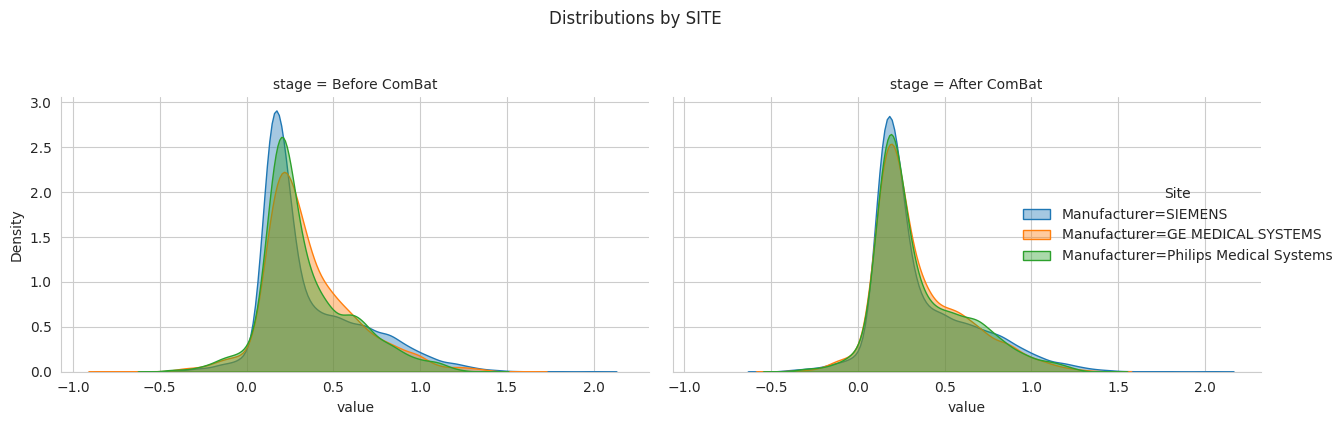

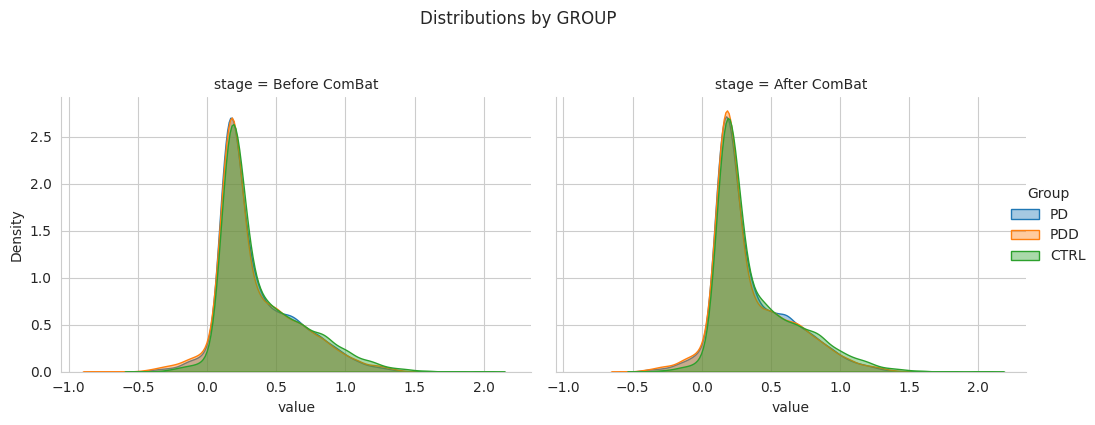

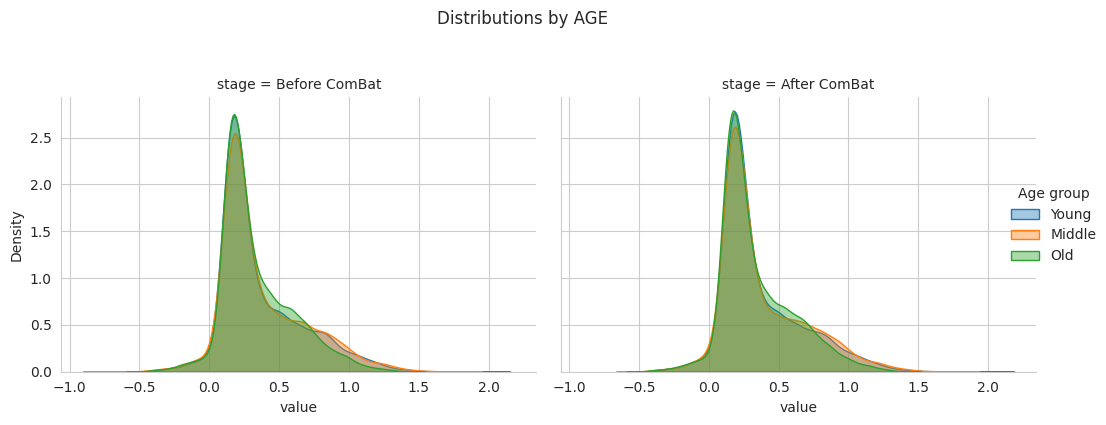

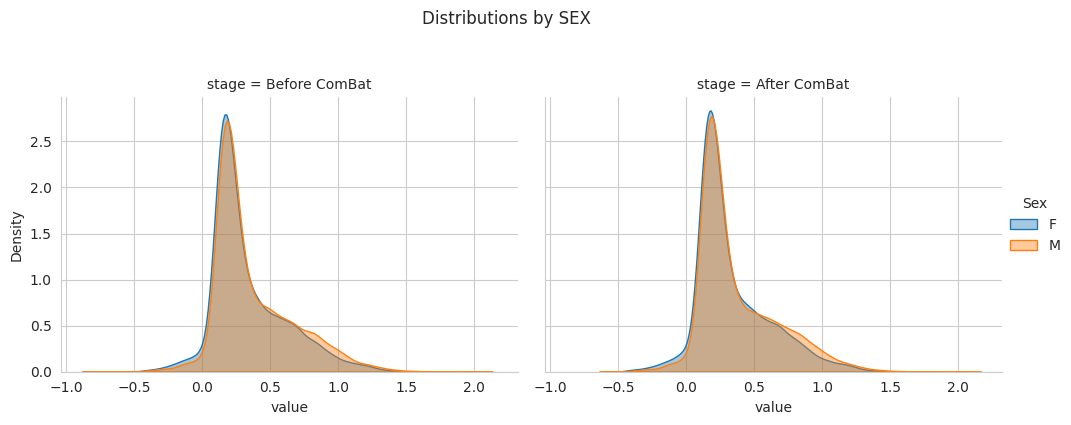

In [ ]:
#@title Harmonization
model, X_harmonized, group, batch, age, sex = get_harmonization(
    both_metrics_pd,both_metrics_pdd,both_metrics_ctrl
)

plot_combat_distributions(
    X_before = np.vstack([both_metrics_pd,both_metrics_pdd,both_metrics_ctrl]),
    X_after  = X_harmonized,
    group    = group,
    site     = batch,
    age      = age,
    sex      = sex
)

In [ ]:
n_pd = both_metrics_pd.shape[0]
n_pdd = both_metrics_pdd.shape[0]

X_pd_h = X_harmonized[:n_pd]
X_pdd_h = X_harmonized[n_pd:n_pd+n_pdd]

In [ ]:
X_pd_pdd = np.vstack([X_pd_h, X_pdd_h])
gdsc_pd_pdd = np.concatenate([gdsc_pd, gdsc_pdd])

group_pd_pdd = np.array(["PD"] * n_pd + ["PDD"] * n_pdd)
mask_pdd = group_pd_pdd == "PDD"

In [ ]:
var_features = X_pd_pdd[:, :105]
mean_features = X_pd_pdd[:, 105:]

In [ ]:
global_var = np.mean(var_features, axis=1)
spearmanr(global_var[mask_pdd], gdsc_pd_pdd[mask_pdd])

SignificanceResult(statistic=np.float64(-0.03355479439559365), pvalue=np.float64(0.8707331729970565))

In [ ]:
global_mean = np.mean(mean_features, axis=1)
spearmanr(global_mean[mask_pdd], gdsc_pd_pdd[mask_pdd])

SignificanceResult(statistic=np.float64(-0.20382752765834014), pvalue=np.float64(0.3179200016564059))

In [ ]:
def extract_node_var(var_features, node_idx, n_roi=15):
    rows, cols = np.triu_indices(n_roi, k=1)

    node_edges = [i for i, (r, c) in enumerate(zip(rows, cols))
                  if r == node_idx or c == node_idx]

    return np.mean(var_features[:, node_edges], axis=1)

mpfc_var = extract_node_var(var_features, mpfc_idx)

spearmanr(mpfc_var[mask_pdd], gdsc_pd_pdd[mask_pdd])

SignificanceResult(statistic=np.float64(0.17991081250403404), pvalue=np.float64(0.37915247022845844))

In [ ]:
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X_harmonized)

Significant (uncorrected): 4
Feature 70: increase (group2 > group1)
Feature 72: increase (group2 > group1)
Feature 142: decrease (group2 < group1)
Feature 186: increase (group2 > group1)
p_values: [0.01570777 0.04131137 0.03686131 0.04452431]
networks.Salience.AInsula (R) (47,14,0) <-> networks.Salience.RPFC (R) (32,46,27)
networks.Salience.AInsula (R) (47,14,0) <-> networks.Salience.SMG (R) (62,-35,32)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.LPFC (R)  (41,38,30)
networks.Salience.RPFC (L) (-32,45,27) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
Significant after FDR: 0


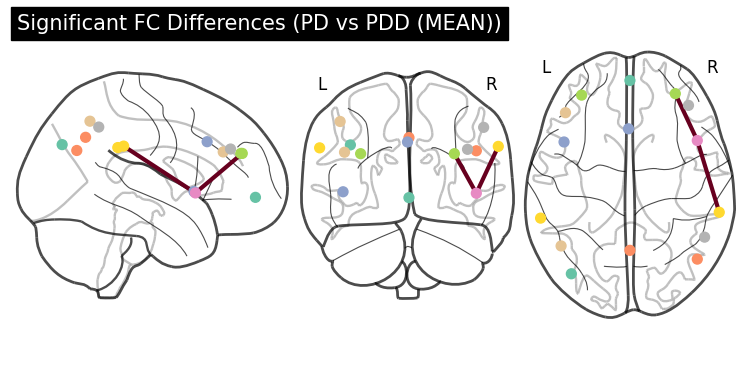

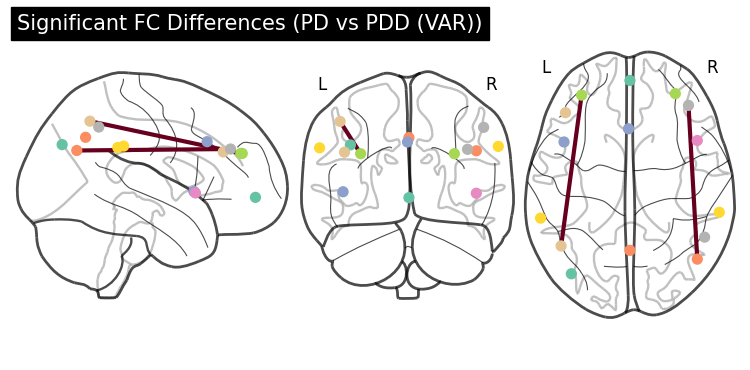

In [ ]:
#@title Statistical Test PD vs PDD
group_array = np.array(group)
idx_1 = group_array == "PD"
idx_2 = group_array == "PDD"

p_values, list_index = statistical_test(X=X_harmonized, index_1=idx_1, index_2=idx_2)
print(f"p_values: {p_values.flatten()[list_index]}")

mean_idx = [i for i in list_index if i < 105]
var_idx  = [i for i in list_index if i >= 105]
var_idx_adjusted = [i - 105 for i in var_idx]

matrix_mean = get_connection(mean_idx)
matrix_var  = get_connection(var_idx_adjusted)

coordinates = obtain_coordinates()

statistical_correction(p_values)

p_values[list_index]

plot_connections(matrix_mean, coordinates, group1="PD", group2="PDD (MEAN)")
plot_connections(matrix_var, coordinates, group1="PD", group2="PDD (VAR)")

In [ ]:
save_to_plot(matrix_mean,coordinates,get_list_names(), name = "DC_PD_PDD_MEAN")
save_to_plot(matrix_var,coordinates,get_list_names(), name = "DC_PD_PDD_VARIABILITY")

In [ ]:
#PD > PDD
for i in mean_idx:
    mean_pd = np.mean(X_harmonized[idx_1, i])
    mean_pdd = np.mean(X_harmonized[idx_2, i])

    print(i, "PD:", mean_pd, "PDD:", mean_pdd)

for i in var_idx:
    var_pd = np.mean(X_harmonized[idx_1, i])
    var_pdd = np.mean(X_harmonized[idx_2, i])

    print(i, "PD:", var_pd, "PDD:", var_pdd)

70 PD: 0.16342246893260853 PDD: 0.20281143686960895
72 PD: 0.14799650350762453 PDD: 0.18447246694429642
142 PD: 0.6746199989622416 PDD: 0.5631247442712689
186 PD: 0.4577791203026358 PDD: 0.5946980470323463


Significant (uncorrected): 13
Feature 19: decrease (group2 < group1)
Feature 61: decrease (group2 < group1)
Feature 106: decrease (group2 < group1)
Feature 113: decrease (group2 < group1)
Feature 123: decrease (group2 < group1)
Feature 133: decrease (group2 < group1)
Feature 135: decrease (group2 < group1)
Feature 136: decrease (group2 < group1)
Feature 137: decrease (group2 < group1)
Feature 138: decrease (group2 < group1)
Feature 139: decrease (group2 < group1)
Feature 142: decrease (group2 < group1)
Feature 155: decrease (group2 < group1)
p_values: [0.04131137 0.04131137 0.03686131 0.00454277 0.02386573 0.03282622
 0.038297   0.00667367 0.0105776  0.01784927 0.03282622 0.00432513
 0.02198921]
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.Salience.RPFC (L) (-32,45,27)
networks.Salience.AInsula (L) (-44,13,1) <-> networks.Salience.RPFC (L) (-32,45,27)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (R) (47,-67,29)
networks.DefaultMode.MPFC (1,55,-3) <-> network

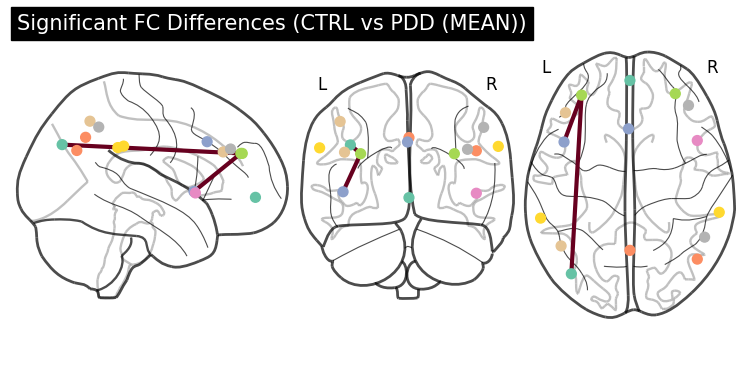

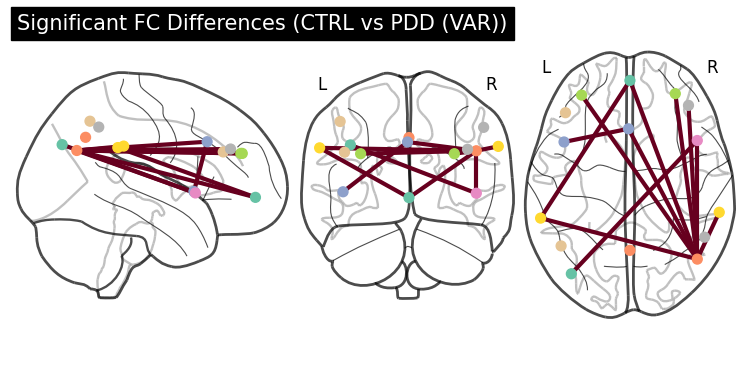

In [ ]:
#@title Statistical Test CTRL vs PDD
group_array = np.array(group)
idx_1 = group_array == "CTRL"
idx_2 = group_array == "PDD"

p_values, list_index = statistical_test(X=X_harmonized, index_1=idx_1, index_2=idx_2)
print(f"p_values: {p_values.flatten()[list_index]}")
mean_idx = [i for i in list_index if i < 105]
var_idx  = [i for i in list_index if i >= 105]

var_idx_adjusted = [i - 105 for i in var_idx]

matrix_mean = get_connection(mean_idx)
matrix_var  = get_connection(var_idx_adjusted)

coordinates = obtain_coordinates()

statistical_correction(p_values)

p_values[list_index]
plot_connections(matrix_mean, coordinates, group1="CTRL", group2="PDD (MEAN)")
plot_connections(matrix_var, coordinates, group1="CTRL", group2="PDD (VAR)")

In [ ]:
save_to_plot(matrix_mean,coordinates,get_list_names(), name = "DC_CTRL_PDD_MEAN")
save_to_plot(matrix_var,coordinates,get_list_names(), name = "DC_CTRL_PDD_VARIABILITY")

In [ ]:
# CTRL > PDD

for i in mean_idx:
    ctrl_val = np.mean(X_harmonized[idx_1, i])
    pdd_val  = np.mean(X_harmonized[idx_2, i])

    print(i, "CTRL:", ctrl_val, "PDD:", pdd_val)

for i in var_idx:
    ctrl_val = np.mean(X_harmonized[idx_1, i])
    pdd_val  = np.mean(X_harmonized[idx_2, i])

    print(i, "CTRL:", ctrl_val, "PDD:", pdd_val)

19 CTRL: 0.2217215441850065 PDD: 0.19288812092206753
61 CTRL: 0.17715661032232255 PDD: 0.14771308603035938
106 CTRL: 0.7132537292744736 PDD: 0.5742857742380282
113 CTRL: 0.2866733371710467 PDD: 0.058917158855100855
123 CTRL: 0.22322956843496564 PDD: 0.05964586097367194
133 CTRL: 0.4911568460664936 PDD: 0.3043702467433877
135 CTRL: 0.37822564560861993 PDD: 0.20507221535283368
136 CTRL: 0.5054075551238257 PDD: 0.3045461944219008
137 CTRL: 0.514173561091779 PDD: 0.31192012213946596
138 CTRL: 0.32690586263468435 PDD: 0.13695483470686526
139 CTRL: 0.44956277642423836 PDD: 0.26673720443023397
142 CTRL: 0.7540979295344281 PDD: 0.5631247442712689
155 CTRL: 0.8663679664261144 PDD: 0.6745230787975888


Significant (uncorrected): 12
Feature 24: decrease (group2 < group1)
Feature 36: decrease (group2 < group1)
Feature 46: decrease (group2 < group1)
Feature 47: decrease (group2 < group1)
Feature 72: decrease (group2 < group1)
Feature 80: decrease (group2 < group1)
Feature 110: decrease (group2 < group1)
Feature 113: decrease (group2 < group1)
Feature 129: decrease (group2 < group1)
Feature 131: decrease (group2 < group1)
Feature 138: decrease (group2 < group1)
Feature 197: decrease (group2 < group1)
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
networks.DefaultMode.PCC (1,-61,38) <-> networks.FrontoParietal.LPFC (L)  (-43,33,28)
networks.DefaultMode.PCC (1,-61,38) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
networks.Salience.AInsula (R) (47,14,0) <-> networks.Salience.SMG (R) (62,-35,32)
networks.Salience.RPFC (L) (-32,45,27) <-> networks.FrontoPar

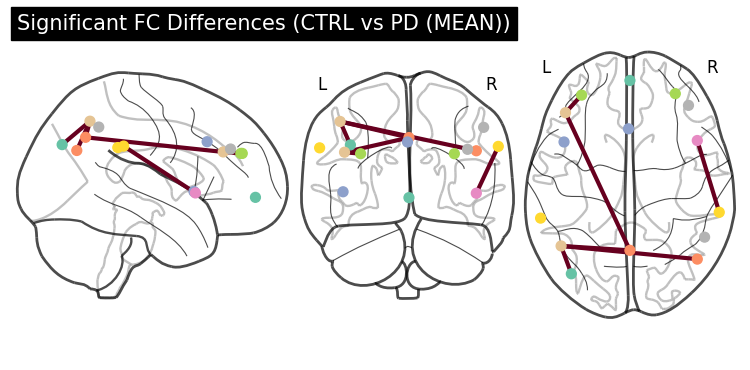

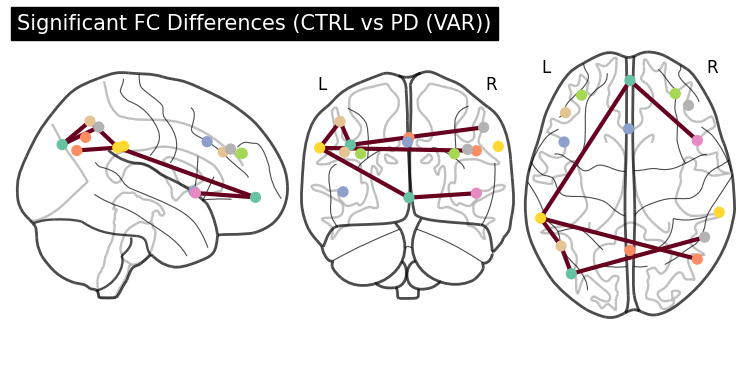

In [ ]:
#@title Statistical Test CTRL vs PD
group_array = np.array(group)
idx_1 = group_array == "CTRL"
idx_2 = group_array == "PD"

p_values, list_index = statistical_test(X=X_harmonized, index_1=idx_1, index_2=idx_2)


mean_idx = [i for i in list_index if i < 105]
var_idx  = [i for i in list_index if i >= 105]
var_idx_adjusted = [i - 105 for i in var_idx]

matrix_mean = get_connection(mean_idx)
matrix_var  = get_connection(var_idx_adjusted)

coordinates = obtain_coordinates()

statistical_correction(p_values)

p_values[list_index]
plot_connections(matrix_mean, coordinates, group1="CTRL", group2="PD (MEAN)")
plot_connections(matrix_var, coordinates, group1="CTRL", group2="PD (VAR)")

In [ ]:
save_to_plot(matrix_mean,coordinates,get_list_names(), name = "DC_CTRL_PD_MEAN")
save_to_plot(matrix_var,coordinates,get_list_names(), name = "DC_CTRL_PD_VARIABILITY")

In [ ]:
# CTRL > PD

for i in mean_idx:
    ctrl_mean = np.mean(X_harmonized[idx_1, i])
    pd_mean   = np.mean(X_harmonized[idx_2, i])

    print(i, "CTRL_mean:", ctrl_mean, "PD_mean:", pd_mean)


for i in var_idx:
    ctrl_var = np.mean(X_harmonized[idx_1, i])
    pd_var   = np.mean(X_harmonized[idx_2, i])

    print(i, "CTRL_var:", ctrl_var, "PD_var:", pd_var)

24 CTRL_mean: 0.23318009934746498 PD_mean: 0.19066272350696228
36 CTRL_mean: 0.2077292130087226 PD_mean: 0.17990557733016713
46 CTRL_mean: 0.2335024248422966 PD_mean: 0.20516274712453475
47 CTRL_mean: 0.22848316641784008 PD_mean: 0.18568361112111165
72 CTRL_mean: 0.1867669742555292 PD_mean: 0.14799650350762453
80 CTRL_mean: 0.23055487283999238 PD_mean: 0.1853856592956852
110 CTRL_var: 0.4003103240970398 PD_var: 0.21821689437729266
113 CTRL_var: 0.2866733371710467 PD_var: 0.10853638905562887
129 CTRL_var: 0.8147357855611852 PD_var: 0.6830070805415291
131 CTRL_var: 0.5132083585118816 PD_var: 0.3774291012959845
138 CTRL_var: 0.32690586263468435 PD_var: 0.18498799403374855
197 CTRL_var: 0.44797312457897975 PD_var: 0.2918386780634188


#**EFFECTIVE FUNCTIONAL CONNECTIVITY**

In [ ]:
def get_all_flatten_granger(G_list):
    nROI = G_list[0].shape[0]
    rows, cols = np.where(~np.eye(nROI, dtype=bool))
    features = []
    for G in G_list:
        vec = G[~np.eye(nROI, dtype=bool)]
        features.append(vec)

    return np.array(features), rows, cols

In [ ]:
g_values = sio.loadmat(ROOT_PATH/"GC_results.mat")
g_values.keys()
G_ctrl = g_values['G_ctrl']
G_pd   = g_values['G_pd']
G_pdd  = g_values['G_pdd']
G_ctrl_list = [G_ctrl[i,0] for i in range(G_ctrl.shape[0])]
G_pd_list   = [G_pd[i,0] for i in range(G_pd.shape[0])]
G_pdd_list  = [G_pdd[i,0] for i in range(G_pdd.shape[0])]

In [ ]:
matrix_flatten_ctrl, rows, cols = get_all_flatten_granger(G_ctrl_list)
matrix_flatten_pd, _, _         = get_all_flatten_granger(G_pd_list)
matrix_flatten_pdd, _, _        = get_all_flatten_granger(G_pdd_list)

In [ ]:
print(matrix_flatten_ctrl.shape)
print(matrix_flatten_pd.shape)
print(matrix_flatten_pdd.shape)

(32, 210)
(32, 210)
(26, 210)


(90, 210)
90
90
dict_keys(['design', 'SITE_labels', 'var_pooled', 'B_hat', 'stand_mean', 'mod_mean', 'gamma_star', 'delta_star', 'info_dict', 'gamma_hat', 'delta_hat', 'gamma_bar', 't2', 'a_prior', 'b_prior', 'smooth_model', 'eb', 'SITE_labels_train', 'Covariates', 'ref_batch'])
(90, 210) (90, 210)
0 0


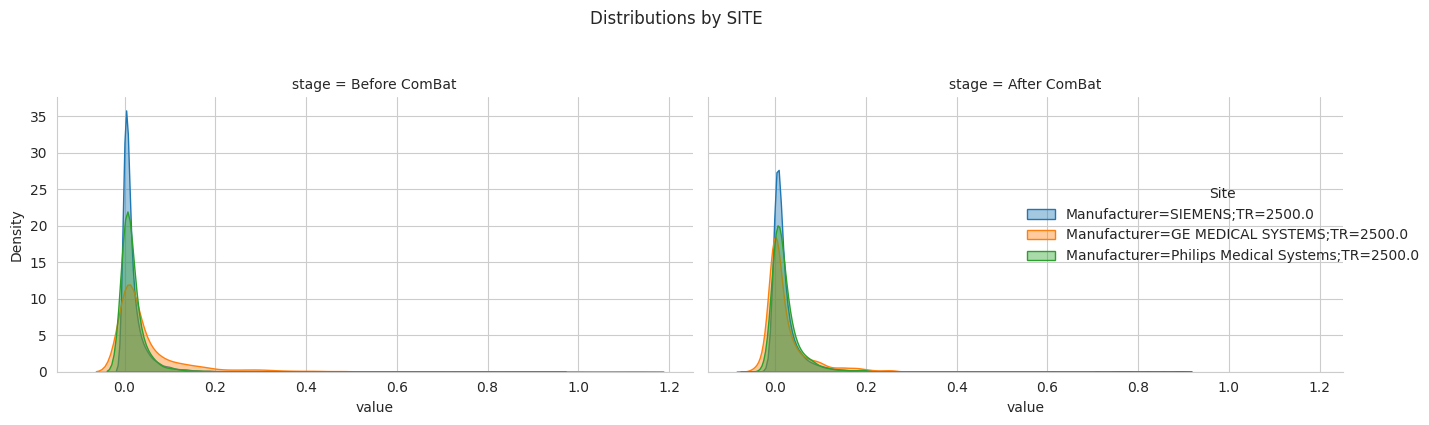

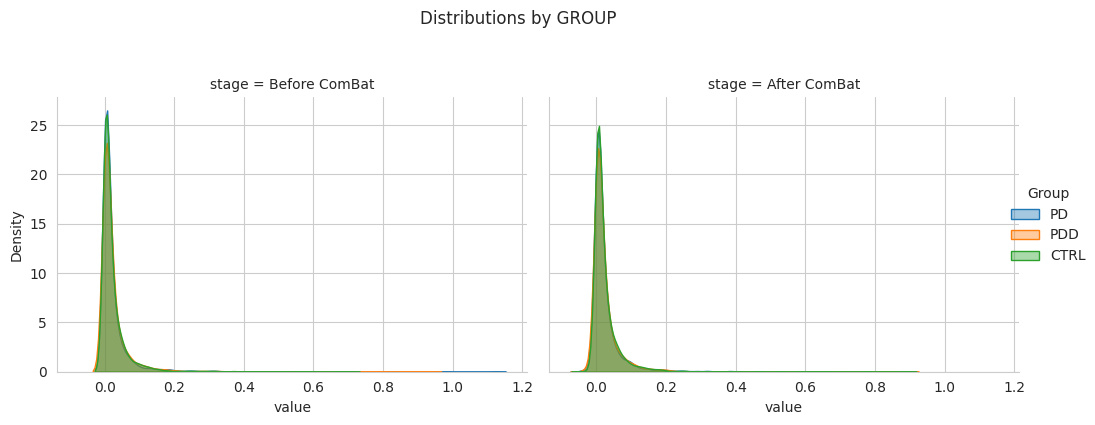

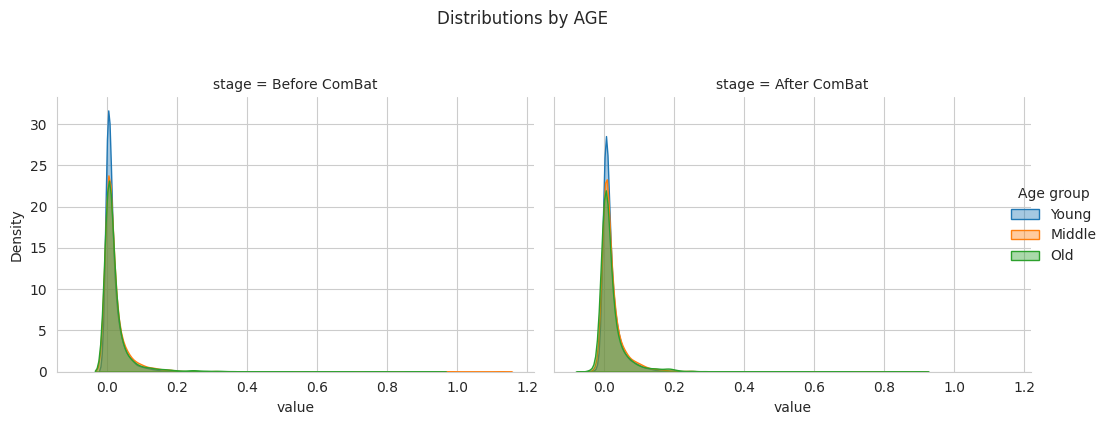

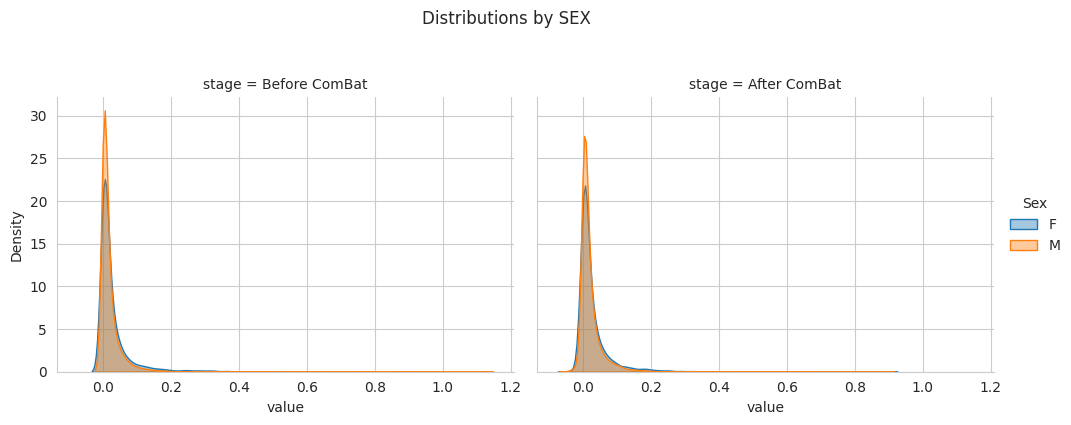

In [ ]:
#@title Harmonization
model, X_harmonized, group, batch, age, sex = get_harmonization(
    matrix_flatten_pd,matrix_flatten_pdd,matrix_flatten_ctrl
)

plot_combat_distributions(
    X_before = np.vstack([matrix_flatten_pd,matrix_flatten_pdd,matrix_flatten_ctrl]),
    X_after  = X_harmonized,
    group    = group,
    site     = batch,
    age      = age,
    sex      = sex
)

In [ ]:
def statistical_test_uncorrected(X, idx_1, idx_2):
    p_values = []
    directions = []

    for i in range(X.shape[1]):
        x1 = X[idx_1, i]
        x2 = X[idx_2, i]

        _, p = mannwhitneyu(x1, x2, alternative="two-sided")
        p_values.append(p)

        if np.median(x2) > np.median(x1):
            directions.append("increase (group2 > group1)")
        elif np.median(x2) < np.median(x1):
            directions.append("decrease (group2 < group1)")
        else:
            directions.append("no change")

    p_values = np.array(p_values)

    list_index = np.where(p_values < 0.05)[0]

    print("Significant (uncorrected):", len(list_index))
    for idx in list_index:
        print(f"Feature {idx}: {directions[idx]}")

    return p_values, list_index

def get_connection(list_index, rows, cols, roi_names):
    n_rois = len(roi_names)
    matrix = np.zeros((n_rois, n_rois), dtype=int)

    for idx in list_index:
        i = rows[idx]
        j = cols[idx]

        print(f"{roi_names[i]} → {roi_names[j]}")
        matrix[i, j] = 1   # directed edge

    return matrix


Significant (uncorrected): 3
Feature 91: increase (group2 > group1)
Feature 103: increase (group2 > group1)
Feature 199: decrease (group2 < group1)
p_values: [0.00320633 0.03412706 0.02024238]
networks.Salience.AInsula (R) (47,14,0) → networks.Salience.RPFC (R) (32,46,27)
networks.Salience.RPFC (L) (-32,45,27) → networks.Salience.AInsula (L) (-44,13,1)
networks.FrontoParietal.PPC (R)  (52,-52,45) → networks.DefaultMode.PCC (1,-61,38)


/tmp/ipykernel_5779/1646545693.py:2: UserWarning: 'adjacency_matrix' is not symmetric.
A directed graph will be plotted.
  plotting.plot_connectome(


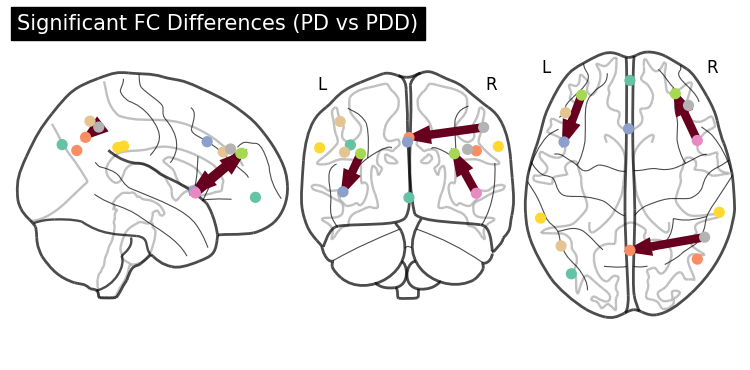

In [ ]:
#@title Statistical Test PD vs PDD
group_array = np.array(group)

idx_pd  = group_array == "PD"
idx_pdd = group_array == "PDD"

p_values, list_index = statistical_test_uncorrected(
    X_harmonized,
    idx_pd,
    idx_pdd
)
print(f"p_values: {p_values.flatten()[list_index]}")
roi_names = get_roi_names()
connection_matrix = get_connection(list_index, rows, cols, roi_names)
coordinates = obtain_coordinates()
plot_connections(connection_matrix, coordinates, group1="PD", group2="PDD")

In [ ]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "GC_PD_PDD")

Significant (uncorrected): 2
Feature 18: increase (group2 > group1)
Feature 197: decrease (group2 < group1)
p_values: [0.02694054 0.04973741]
networks.DefaultMode.LP (L) (-39,-77,33) → networks.Salience.AInsula (L) (-44,13,1)
networks.FrontoParietal.PPC (R)  (52,-52,45) → networks.DefaultMode.LP (L) (-39,-77,33)


/tmp/ipykernel_5779/1646545693.py:2: UserWarning: 'adjacency_matrix' is not symmetric.
A directed graph will be plotted.
  plotting.plot_connectome(


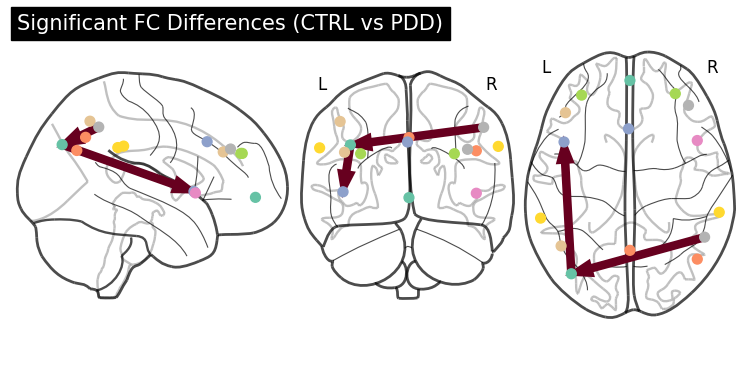

In [ ]:
#@title Statistical Test CTRL vs PDD
group_array = np.array(group)

idx_ctrl  = group_array == "CTRL"
idx_pdd = group_array == "PDD"

p_values, list_index = statistical_test_uncorrected(
    X_harmonized,
    idx_ctrl,
    idx_pdd
)
print(f"p_values: {p_values.flatten()[list_index]}")
roi_names = get_roi_names()
connection_matrix = get_connection(list_index, rows, cols, roi_names)
coordinates = obtain_coordinates()
plot_connections(connection_matrix, coordinates, group1="CTRL", group2="PDD")

In [ ]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "GC_CTRL_PDD")

Significant (uncorrected): 4
Feature 49: decrease (group2 < group1)
Feature 89: increase (group2 > group1)
Feature 147: decrease (group2 < group1)
Feature 199: increase (group2 > group1)
networks.DefaultMode.PCC (1,-61,38) → networks.Salience.RPFC (R) (32,46,27)
networks.Salience.AInsula (R) (47,14,0) → networks.Salience.AInsula (L) (-44,13,1)
networks.Salience.SMG (R) (62,-35,32) → networks.Salience.RPFC (L) (-32,45,27)
networks.FrontoParietal.PPC (R)  (52,-52,45) → networks.DefaultMode.PCC (1,-61,38)


/tmp/ipykernel_5779/1646545693.py:2: UserWarning: 'adjacency_matrix' is not symmetric.
A directed graph will be plotted.
  plotting.plot_connectome(


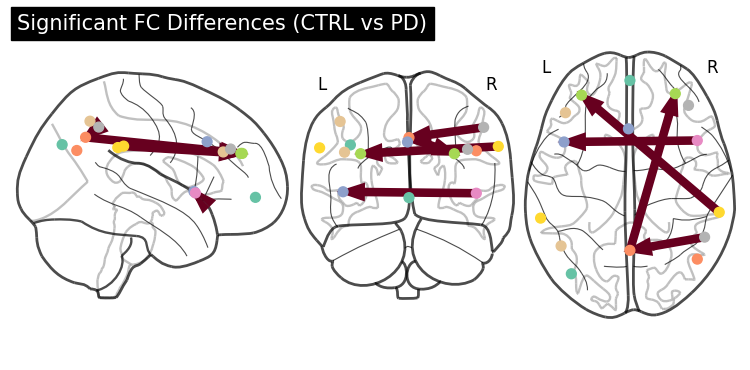

In [ ]:
#@title Statistical Test CTRL vs PD
group_array = np.array(group)

idx_ctrl  = group_array == "CTRL"
idx_pd = group_array == "PD"

p_values, list_index = statistical_test_uncorrected(
    X_harmonized,
    idx_ctrl,
    idx_pd
)

roi_names = get_roi_names()
connection_matrix = get_connection(list_index, rows, cols, roi_names)
coordinates = obtain_coordinates()
plot_connections(connection_matrix, coordinates, group1="CTRL", group2="PD")

In [ ]:
save_to_plot(connection_matrix,coordinates,get_list_names(), name = "GC_CTRL_PD")

#**BRAIN GLASS**

In [ ]:
coordinates = obtain_coordinates()
names_list = get_list_names()
color_list = get_colors(len(coordinates))

view = plotting.view_markers(
    marker_coords=coordinates,
    marker_labels=names_list,
    marker_color=color_list,
    marker_size = 10,
    title = "Regions of Interest (ROIs) Included in the Analysis"
)
view

In [ ]:
from nilearn import plotting

# Get your data
coordinates = obtain_coordinates()
names_list = get_list_names()

# --- Define colors per network ---
color_map = {
    "DMN": "#1f77b4",   # blue
    "SAL": "#d62728",   # red
    "FPN": "#2ca02c"    # green
}

# --- Assign colors based on ROI name ---
marker_color = []
for name in names_list:
    if "DMN" in name:
        marker_color.append(color_map["DMN"])
    elif "SAL" in name:
        marker_color.append(color_map["SAL"])
    elif "FPN" in name:
        marker_color.append(color_map["FPN"])
    else:
        marker_color.append("gray")  # fallback (just in case)

# --- Optional: clean labels (remove network prefix) ---
clean_labels = [
    name.replace("DMN.", "")
        .replace("SAL.", "")
        .replace("FPN.", "")
    for name in names_list
]

# --- Marker size (uniform) ---
marker_size = 10

# --- Create interactive view ---
view = plotting.view_markers(
    marker_coords=coordinates,
    marker_labels=clean_labels,
    marker_color=marker_color,
    marker_size=marker_size,
    ##title="Regions of Interest (ROIs)"
)

view

In [ ]:
get_list_names()

['DMN.MPFC',
 'DMN.LP (L)',
 'DMN.LP (R)',
 'DMN.PCC',
 'SAL.ACC',
 'SAL.AInsula (L)',
 'SAL.AInsula (R)',
 'SAL.RPFC (L)',
 'SAL.RPFC (R)',
 'SAL.SMG (L)',
 'SAL.SMG (R)',
 'FPN.LPFC (L)',
 'FPN.PPC (L)',
 'FPN.LPFC (R)',
 'FPN.PPC (R)']

#**ADDITIONAL METRICS**

In [ ]:
def compute_group_stats(age, sex, gds):
    N = len(age)

    age_mean = np.mean(age)
    age_std  = np.std(age)

    n_male = np.sum(np.array(sex) == "M")
    n_female = np.sum(np.array(sex) == "F")

    gds_mean = np.mean(gds)
    gds_std  = np.std(gds)

    return {
        "N": N,
        "age": f"{age_mean:.2f} ± {age_std:.2f}",
        "sex": f"{n_male}/{n_female}",  # M/F
        "gds": f"{gds_mean:.2f} ± {gds_std:.2f}"
    }

In [ ]:
batch_pd = get_manufacturers_list(list_participants_pd)
batch_pdd = get_manufacturers_list(list_participants_pdd)
batch_ctrl = get_manufacturers_list(list_participants_ctrl)


age_pd = get_age_list(list_participants_pd)
age_pdd = get_age_list(list_participants_pdd)
age_ctrl = get_age_list(list_participants_ctrl)


sex_pd = get_sex_list(list_participants_pd)
sex_pdd = get_sex_list(list_participants_pdd)
sex_ctrl = get_sex_list(list_participants_ctrl)

gdsc_pd = get_gdsc_list(list_participants_pd)
gdsc_pdd = get_gdsc_list(list_participants_pdd)
gdsc_ctrl = get_gdsc_list(list_participants_ctrl)

In [ ]:
stats_ctrl = compute_group_stats(age_ctrl, sex_ctrl, gdsc_ctrl)
stats_pd   = compute_group_stats(age_pd, sex_pd, gdsc_pd)
stats_pdd  = compute_group_stats(age_pdd, sex_pdd, gdsc_pdd)

In [ ]:
print(f"""
Group | N | Age (mean ± SD) | Sex (M/F) | GDS (mean ± SD)
--------------------------------------------------------
CTRL  | {stats_ctrl['N']} | {stats_ctrl['age']} | {stats_ctrl['sex']} | {stats_ctrl['gds']}
PD    | {stats_pd['N']}   | {stats_pd['age']}   | {stats_pd['sex']}   | {stats_pd['gds']}
PDD   | {stats_pdd['N']}  | {stats_pdd['age']}  | {stats_pdd['sex']}  | {stats_pdd['gds']}
""")


Group | N | Age (mean ± SD) | Sex (M/F) | GDS (mean ± SD)
--------------------------------------------------------
CTRL  | 32 | 65.67 ± 12.37 | 18/14 | nan ± nan
PD    | 32   | 64.06 ± 10.52   | 19/13   | 1.03 ± 1.31
PDD   | 26  | 62.91 ± 9.73  | 18/8  | 6.88 ± 2.29



#**EFFECTIVE FUNCTIONAL CONNECTIVITY**

In [ ]:
roi_names = get_roi_names()
roi_names
roi_names_clean = [str(r) for r in roi_names]
DMN = [i for i, r in enumerate(roi_names_clean) if "DefaultMode" in r]
SAL = [i for i, r in enumerate(roi_names_clean) if "Salience" in r]
FPN = [i for i, r in enumerate(roi_names_clean) if "FrontoParietal" in r]

print("DMN:", DMN)
print("SAL:", SAL)
print("FPN:", FPN)

DMN: [0, 1, 2, 3]
SAL: [4, 5, 6, 7, 8, 9, 10]
FPN: [11, 12, 13, 14]


In [ ]:
mpfc_idx = [i for i, r in enumerate(roi_names_clean) if "MPFC" in r][0]
print("mPFC index:", mpfc_idx)

mPFC index: 0


In [ ]:
from pathlib import Path

ROOT_PATH_NEW = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/matlab_to_python/GC_results_with_statistics.mat")
import scipy.io as sio

data = sio.loadmat(str(ROOT_PATH_NEW))

GC_ctrl = data['GC_ctrl']
GC_pd   = data['GC_pd']
GC_pdd  = data['GC_pdd']

In [ ]:
#@title ComBat Harmonization Variables

import numpy as np
import pandas as pd
from neuroHarmonize import harmonizationLearn

def get_harmonization(matrix_flatten_pd, matrix_flatten_pdd, matrix_flatten_ctrl):

    # -------- STACK DATA --------
    X = np.vstack([
        matrix_flatten_pd,
        matrix_flatten_pdd,
        matrix_flatten_ctrl
    ])

    group = (
        ["PD"]   * len(matrix_flatten_pd) +
        ["PDD"]  * len(matrix_flatten_pdd) +
        ["CTRL"] * len(matrix_flatten_ctrl)
    )

    # -------- BATCH (SITE / MANUFACTURER) --------
    batch_pd   = get_manufacturers_list(list_participants_pd)
    batch_pdd  = get_manufacturers_list(list_participants_pdd)
    batch_ctrl = get_manufacturers_list(list_participants_ctrl)

    batch = np.concatenate([batch_pd, batch_pdd, batch_ctrl])

    # OPTIONAL (recommended): keep only manufacturer name
    batch = np.array([b.split(";")[0] for b in batch])

    # -------- AGE --------
    age = np.concatenate([
        get_age_list(list_participants_pd),
        get_age_list(list_participants_pdd),
        get_age_list(list_participants_ctrl)
    ])

    # -------- SEX --------
    sex = np.concatenate([
        get_sex_list(list_participants_pd),
        get_sex_list(list_participants_pdd),
        get_sex_list(list_participants_ctrl)
    ])

    # Encode: F=1, M=0
    sex_encoded = (np.array(sex) == "F").astype(float)

    # -------- DEBUG --------
    print("X shape:", X.shape)
    print("Group length:", len(group))
    print("Batch length:", len(batch))

    # -------- GROUP DUMMIES (correct approach) --------
    group_dummies = pd.get_dummies(group, prefix="GROUP", drop_first=True).astype(float)

    # -------- COVARIATES --------
    covars = pd.DataFrame({
        "SITE": batch,                      # categorical (batch)
        "AGE": age.astype(float),           # numeric
        "SEX": sex_encoded.astype(float)    # numeric
    })

    covars = pd.concat([covars, group_dummies], axis=1)

    # -------- COMBAT --------
    model, X_harmonized = harmonizationLearn(
        data=X,
        covars=covars
    )

    # -------- CHECKS --------
    print("Output shape:", X_harmonized.shape)
    print("NaNs:", np.isnan(X_harmonized).sum())
    print("Infs:", np.isinf(X_harmonized).sum())

    return model, X_harmonized, group, batch, age, sex_encoded

In [ ]:
import numpy as np

def flatten_gc(GC):
    n_sub, n_roi, _ = GC.shape
    mask = ~np.eye(n_roi, dtype=bool)

    return GC[:, mask]

matrix_ctrl = flatten_gc(GC_ctrl)
matrix_pd   = flatten_gc(GC_pd)
matrix_pdd  = flatten_gc(GC_pdd)

In [ ]:
model, X_harmonized, group, batch, age, sex = get_harmonization(
    matrix_pd, matrix_pdd, matrix_ctrl
)

X shape: (90, 210)
Group length: 90
Batch length: 90
Output shape: (90, 210)
NaNs: 0
Infs: 0


In [ ]:
n_pd = len(matrix_pd)
n_pdd = len(matrix_pdd)
n_ctrl = len(matrix_ctrl)

X_pd_h   = X_harmonized[:n_pd]
X_pdd_h  = X_harmonized[n_pd:n_pd+n_pdd]
X_ctrl_h = X_harmonized[n_pd+n_pdd:]

In [ ]:
def unflatten_gc(X, n_roi):
    mask = ~np.eye(n_roi, dtype=bool)
    GC = np.zeros((X.shape[0], n_roi, n_roi))
    GC[:, mask] = X
    return GC

GC_ctrl_h = unflatten_gc(X_ctrl_h, 15)
GC_pd_h   = unflatten_gc(X_pd_h, 15)
GC_pdd_h  = unflatten_gc(X_pdd_h, 15)

In [ ]:
import scipy.io as sio
from pathlib import Path

SAVE_PATH = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/matlab_to_python/GC_harmonized.mat")

sio.savemat(str(SAVE_PATH), {
    'GC_ctrl_h': GC_ctrl_h,
    'GC_pd_h': GC_pd_h,
    'GC_pdd_h': GC_pdd_h
})

In [ ]:
GC_all = np.vstack([GC_pd, GC_pdd, GC_ctrl])
gdsc_pd   = get_gdsc_list(list_participants_pd)
gdsc_pdd  = get_gdsc_list(list_participants_pdd)
gdsc_ctrl = get_gdsc_list(list_participants_ctrl)

gdsc = np.concatenate([gdsc_pd, gdsc_pdd, gdsc_ctrl])

In [ ]:
def compute_network_gc(GC, source_idx, target_idx):
    values = []

    for subj in range(GC.shape[0]):   # loop over subjects
        mat = GC[subj]               # 15x15 matrix

        # extract connections from source → target
        sub_vals = mat[np.ix_(source_idx, target_idx)]

        # average them
        values.append(np.mean(sub_vals))

    return np.array(values)

In [ ]:
sal_to_fpn = compute_network_gc(GC_all, SAL, FPN)
dmn_to_fpn = compute_network_gc(GC_all, DMN, FPN)
sal_to_dmn = compute_network_gc(GC_all, SAL, DMN)

mpfc_in = np.mean(GC_all[:, :, mpfc_idx], axis=1)
mpfc_out = np.mean(GC_all[:, mpfc_idx, :], axis=1)

In [ ]:
sal_to_fpn.shape

(90,)

In [ ]:
from scipy.stats import spearmanr
spearmanr(sal_to_fpn, gdsc)

SignificanceResult(statistic=nan, pvalue=nan)

In [ ]:
print(np.isnan(sal_to_fpn).sum())
print(np.isnan(gdsc).sum())

0
3


In [ ]:
n_pd = len(GC_pd)
n_pdd = len(GC_pdd)

GC_pd_pdd = np.vstack([GC_pd, GC_pdd])
gdsc_pd_pdd = np.concatenate([gdsc_pd, gdsc_pdd])

In [ ]:
sal_to_fpn_pd = compute_network_gc(GC_pd_pdd, SAL, FPN)
spearmanr(sal_to_fpn_pd, gdsc_pd_pdd)

SignificanceResult(statistic=np.float64(0.14120572475562945), pvalue=np.float64(0.2903794518587616))

In [ ]:
dmn_to_fpn_pd = compute_network_gc(GC_pd_pdd, DMN, FPN)
spearmanr(dmn_to_fpn_pd, gdsc_pd_pdd)

SignificanceResult(statistic=np.float64(0.17767214226727152), pvalue=np.float64(0.18210583716272394))

In [ ]:
sal_to_dmn_pd = compute_network_gc(GC_pd_pdd, SAL, DMN)
spearmanr(sal_to_dmn_pd, gdsc_pd_pdd)


SignificanceResult(statistic=np.float64(-0.029116839368215065), pvalue=np.float64(0.8282348151988006))

In [ ]:
mpfc_in_pd = np.mean(GC_pd_pdd[:, :, mpfc_idx], axis=1)
mpfc_out_pd = np.mean(GC_pd_pdd[:, mpfc_idx, :], axis=1)

spearmanr(mpfc_in_pd, gdsc_pd_pdd)
spearmanr(mpfc_out_pd, gdsc_pd_pdd)


SignificanceResult(statistic=np.float64(0.10239369719821283), pvalue=np.float64(0.4443636868692711))

In [ ]:
mask_pdd = (group == "PDD")

sal_to_fpn_pdd_only = sal_to_fpn[mask_pdd]
gdsc_pdd_only = gdsc[mask_pdd]

In [ ]:
spearmanr(sal_to_fpn_pdd_only, gdsc_pdd_only)

SignificanceResult(statistic=nan, pvalue=nan)

In [ ]:
np.unique(sal_to_fpn_pdd_only)
np.unique(gdsc_pdd_only)

array([], dtype=float64)

In [ ]:
print(np.unique(group))

['CTRL' 'PD' 'PDD']


In [ ]:
group_pd_pdd = ["PD"] * len(GC_pd) + ["PDD"] * len(GC_pdd)
group_pd_pdd = np.array(group_pd_pdd)

In [ ]:
mask_pdd = group_pd_pdd == "PDD"

In [ ]:
sal_to_fpn_pd = compute_network_gc(GC_pd_pdd, SAL, FPN)

sal_to_fpn_pdd_only = sal_to_fpn_pd[mask_pdd]
gdsc_pdd_only = gdsc_pd_pdd[mask_pdd]

In [ ]:
print(len(sal_to_fpn_pdd_only))  # should be ~26

26


In [ ]:
from scipy.stats import spearmanr

spearmanr(sal_to_fpn_pdd_only, gdsc_pdd_only)

#“few studies explicitly test whether causal edges track severity”
# NO clear scaling with severity

SignificanceResult(statistic=np.float64(0.04373579932773381), pvalue=np.float64(0.8319954844616602))

In [ ]:
mpfc_out = np.mean(GC_pd_pdd[:, mpfc_idx, :], axis=1)

In [ ]:
mpfc_in = np.mean(GC_pd_pdd[:, :, mpfc_idx], axis=1)

In [ ]:
from scipy.stats import spearmanr

spearmanr(mpfc_out[mask_pdd], gdsc_pd_pdd[mask_pdd])
spearmanr(mpfc_in[mask_pdd], gdsc_pd_pdd[mask_pdd])

SignificanceResult(statistic=np.float64(0.14084712518196726), pvalue=np.float64(0.4925273233541426))